# 문항 유형별 예측 성능 비교 분석 — RQ2: 일반화 (심층 분석)

## 목적
기존 ML(24 알고리즘) 및 BERT 실험의 prediction 파일을 활용하여, **동일 유형 문항 간 전이**와 **다른 유형 문항 간 전이** 성능을 비교 분석합니다. 과학 탐구 문항의 인지적 유형이 피드백 분류 모델의 일반화에 미치는 영향을 규명합니다.

## 주요 용어
- **전이(Transfer)**: 특정 문항/유형의 데이터로 학습한 모델이 다른 문항/유형의 데이터에서 보이는 성능
- **동일 유형 전이**: 같은 유형의 다른 문항으로의 전이 (예: Q1으로 학습 -> 같은 "자료해석" 유형인 Q3 테스트)
- **다른 유형 전이**: 다른 유형의 문항으로의 전이 (예: Q1으로 학습 -> "예측" 유형인 Q4 테스트)
- **Cohen's Kappa(코헨의 카파)**: 두 평가자 간 일치도를 측정하는 지표로, 우연에 의한 일치를 보정함

## 문항 유형 (4종류, 각 2문항)
| 유형 | 문항 | 설명 |
|:---:|:---:|:---|
| 자료해석/결론 | Q1, Q3 | 실험 데이터 해석 및 결론 도출 |
| 실험설계 | Q2, Q6 | 실험 방법 및 변인 통제 설계 |
| 예측 | Q4, Q5 | 결과 예측 및 근거 제시 |
| 가설평가 | Q7, Q8 | 가설의 타당성 평가 |

## 분석 구성
1. **8x7 문항별 성능 매트릭스**: 모든 문항 쌍 간 전이 성능 (히트맵)
2. **동일 유형 vs 다른 유형**: 유형 일치가 전이에 미치는 영향
3. **2-문항 쌍 학습 효과**: 동일 유형 2문항 동시 학습의 시너지
4. **4x4 유형 수준 전이 매트릭스**: 유형 수준으로 집계한 거시적 패턴
5. **ML vs BERT 종합 비교**: TF-IDF 기반 vs 사전학습 언어모델 비교
6. **유형 수 조합별 전이 성능**: 학습 유형 수(1~3)에 따른 체계적 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score
)
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ──
font_candidates = [
    'AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic',
    'Malgun Gothic', 'NanumBarunGothic'
]
available = {f.name for f in font_manager.fontManager.ttflist}
FONT_NAME = next((f for f in font_candidates if f in available), None)
if FONT_NAME:
    plt.rcParams['font.family'] = FONT_NAME
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print(f'Font: {FONT_NAME}')

Font: AppleGothic


In [ ]:
# ══════════════════════════════════════════════════════════════
#  설정: 경로, 문항 매핑, 유형 정의
# ══════════════════════════════════════════════════════════════

BASE = Path('.')
ML_PRED_DIR = Path('../2_ml/results/generalization/question_combo') / 'predictions'
BERT_BASE = BASE / 'BERT_Results'

ALL_QUESTIONS = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8']

# id 컬럼에서 문항 코드 → 문항 번호 매핑
ID_TO_Q = {
    'aq1': 'Q1', 'aq2': 'Q2', 'aq3': 'Q3', 'aq4': 'Q4',
    'bq1': 'Q5', 'bq2': 'Q6', 'bq3': 'Q7', 'bq4': 'Q8'
}

# 문항 유형 분류
Q_TYPE = {
    'Q1': '자료해석·결론', 'Q3': '자료해석·결론',
    'Q2': '실험설계',       'Q6': '실험설계',
    'Q4': '예측',           'Q5': '예측',
    'Q7': '가설평가',       'Q8': '가설평가'
}

# 동일 유형 쌍
SAME_TYPE_PAIRS = [
    ('Q1', 'Q3'),  # 자료해석·결론
    ('Q2', 'Q6'),  # 실험설계
    ('Q4', 'Q5'),  # 예측
    ('Q7', 'Q8'),  # 가설평가
]

# 동일 유형 파트너 매핑
SAME_TYPE_PARTNER = {}
for a, b in SAME_TYPE_PAIRS:
    SAME_TYPE_PARTNER[a] = b
    SAME_TYPE_PARTNER[b] = a

TYPE_NAMES = ['자료해석·결론', '실험설계', '예측', '가설평가']
TYPE_QUESTIONS = {
    '자료해석·결론': ['Q1', 'Q3'],
    '실험설계': ['Q2', 'Q6'],
    '예측': ['Q4', 'Q5'],
    '가설평가': ['Q7', 'Q8']
}

# BERT prediction 파일 위치 (Pod별)
BERT_PRED_POD = {
    'Q1': 'results 2', 'Q2': 'results 3', 'Q3': 'results 2',
    'Q4': 'results 3', 'Q5': 'results 4', 'Q6': 'results 1',
    'Q7': 'results 2', 'Q8': 'results 3',
    'Q1_Q3': 'results 1', 'Q2_Q6': 'results 1',
    'Q4_Q5': 'results 4', 'Q7_Q8': 'results 1'
}

# ML 모델 목록 (24개)
ML_MODELS = [
    'LR', 'SVM-L', 'SVM-RBF', 'CNB', 'DT', 'RF', 'GB', 'XGB', 'LGBM',
    'C1_Optimal5_HardVoting', 'C1_Optimal5_SoftVoting', 'C1_Optimal5_Stacking',
    'C2_Alt5_HardVoting', 'C2_Alt5_SoftVoting', 'C2_Alt5_Stacking',
    'C3_Optimal3_HardVoting', 'C3_Optimal3_SoftVoting', 'C3_Optimal3_Stacking',
    'C4_Prev4_HardVoting', 'C4_Prev4_SoftVoting', 'C4_Prev4_Stacking',
    'C5_Prev5_HardVoting', 'C5_Prev5_SoftVoting', 'C5_Prev5_Stacking'
]

print('설정 완료')
print(f'ML prediction 경로: {ML_PRED_DIR}')
print(f'BERT prediction 경로: {BERT_BASE}')

In [3]:
# ══════════════════════════════════════════════════════════════
#  헬퍼 함수
# ══════════════════════════════════════════════════════════════

def parse_question(id_series):
    """id 컬럼에서 문항 번호 추출 (예: 72079_aq2_1 → Q2)"""
    code = id_series.str.extract(r'_([ab]q\d)_')[0]
    return code.map(ID_TO_Q)


def compute_metrics(y_true, y_pred):
    """Accuracy, Macro F1, Weighted F1, Cohen's Kappa 산출"""
    if len(y_true) == 0:
        return {'Accuracy': np.nan, 'F1_Macro': np.nan,
                'F1_Weighted': np.nan, 'Kappa': np.nan, 'N': 0}
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1_Macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'F1_Weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Kappa': cohen_kappa_score(y_true, y_pred),
        'N': len(y_true)
    }


def load_ml_predictions(combo_name):
    """ML prediction 파일 로드"""
    path = ML_PRED_DIR / f'predictions_{combo_name}.xlsx'
    df = pd.read_excel(path)
    df['question'] = parse_question(df['id'])
    return df


def load_bert_predictions(combo_name):
    """BERT prediction 파일 로드"""
    pod = BERT_PRED_POD[combo_name]
    path = BERT_BASE / pod / 'predictions' / f'qc_pred_{combo_name}.xlsx'
    df = pd.read_excel(path)
    df['question'] = parse_question(df['id'])
    return df


print('헬퍼 함수 정의 완료')

헬퍼 함수 정의 완료


---
## 1. 데이터 로드: 1-문항 학습 Prediction 파일

**데이터 구조 설명:**
- 각 prediction 파일(예: `predictions_Q1.xlsx`)은 Q1 데이터로 학습한 모델이 **나머지 7개 문항(Q2~Q8)의 피드백**을 예측한 결과
- `id` 컬럼에서 문항 코드를 추출하여 어떤 문항의 피드백인지 식별 (예: `72079_aq2_1` → A2 문항 = Q2)
- `true_label`: 실제 코딩값 (0~6), `predicted_label` 또는 `{모델}_pred`: 모델 예측값
- ML은 24개 알고리즘의 예측이 각각 별도 컬럼으로 저장됨

In [4]:
# ══════════════════════════════════════════════════════════════
#  1-문항 학습 prediction 파일 로드 (ML + BERT)
# ══════════════════════════════════════════════════════════════

ml_preds_1q = {}   # {train_q: DataFrame}
bert_preds_1q = {} # {train_q: DataFrame}

for q in ALL_QUESTIONS:
    ml_preds_1q[q] = load_ml_predictions(q)
    bert_preds_1q[q] = load_bert_predictions(q)

print('=== 1-문항 학습 prediction 파일 로드 완료 ===')
for q in ALL_QUESTIONS:
    ml_n = len(ml_preds_1q[q])
    bert_n = len(bert_preds_1q[q])
    test_qs = sorted(ml_preds_1q[q]['question'].unique())
    print(f'  Train {q}: ML {ml_n}건, BERT {bert_n}건 | 테스트 문항: {test_qs}')

=== 1-문항 학습 prediction 파일 로드 완료 ===
  Train Q1: ML 1815건, BERT 1815건 | 테스트 문항: ['Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8']
  Train Q2: ML 1815건, BERT 1815건 | 테스트 문항: ['Q1', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8']
  Train Q3: ML 1815건, BERT 1815건 | 테스트 문항: ['Q1', 'Q2', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8']
  Train Q4: ML 1815건, BERT 1815건 | 테스트 문항: ['Q1', 'Q2', 'Q3', 'Q5', 'Q6', 'Q7', 'Q8']
  Train Q5: ML 1825건, BERT 1825건 | 테스트 문항: ['Q1', 'Q2', 'Q3', 'Q4', 'Q6', 'Q7', 'Q8']
  Train Q6: ML 1825건, BERT 1825건 | 테스트 문항: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q7', 'Q8']
  Train Q7: ML 1825건, BERT 1825건 | 테스트 문항: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q8']
  Train Q8: ML 1825건, BERT 1825건 | 테스트 문항: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7']


In [5]:
# ══════════════════════════════════════════════════════════════
#  2-문항 동일유형 쌍 prediction 파일 로드 (ML + BERT)
# ══════════════════════════════════════════════════════════════

ml_preds_2q = {}   # {combo_name: DataFrame}
bert_preds_2q = {} # {combo_name: DataFrame}

for qa, qb in SAME_TYPE_PAIRS:
    combo = f'{qa}_{qb}'
    ml_preds_2q[combo] = load_ml_predictions(combo)
    bert_preds_2q[combo] = load_bert_predictions(combo)

print('=== 2-문항 동일유형 쌍 prediction 파일 로드 완료 ===')
for combo in ml_preds_2q:
    ml_n = len(ml_preds_2q[combo])
    bert_n = len(bert_preds_2q[combo])
    q_type = Q_TYPE[combo.split('_')[0]]
    test_qs = sorted(ml_preds_2q[combo]['question'].unique())
    print(f'  Train {combo} ({q_type}): ML {ml_n}건, BERT {bert_n}건 | 테스트 문항: {test_qs}')

=== 2-문항 동일유형 쌍 prediction 파일 로드 완료 ===
  Train Q1_Q3 (자료해석·결론): ML 1550건, BERT 1550건 | 테스트 문항: ['Q2', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8']
  Train Q2_Q6 (실험설계): ML 1560건, BERT 1560건 | 테스트 문항: ['Q1', 'Q3', 'Q4', 'Q5', 'Q7', 'Q8']
  Train Q4_Q5 (예측): ML 1560건, BERT 1560건 | 테스트 문항: ['Q1', 'Q2', 'Q3', 'Q6', 'Q7', 'Q8']
  Train Q7_Q8 (가설평가): ML 1570건, BERT 1570건 | 테스트 문항: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']


---
## 2. 분석 1: 8×7 문항별 성능 매트릭스 (1-문항 학습)

### 읽는 법
- **행(Y축) = 학습 문항**, **열(X축) = 테스트 문항**
- 예: 행 Q1, 열 Q2 → "Q1 데이터로 학습한 모델이 Q2 피드백을 예측한 Kappa"
- **대각선은 비어 있음** (자기 자신은 테스트 불가: 학습에 이미 사용됨)
- **파란 테두리** = 동일 유형 쌍 (예: Q1↔Q3은 둘 다 '자료해석·결론')

### 해석 포인트
- 파란 테두리 셀의 값이 같은 행의 다른 셀보다 높으면 → 동일 유형 전이 우위
- 특정 행의 전체 값이 높으면 → 해당 문항이 일반적으로 좋은 학습 데이터
- 특정 열의 전체 값이 높으면 → 해당 문항이 어떤 데이터로든 잘 예측됨

### ML Best 모델 선정
- 24개 ML 모델 중 **56개 학습-테스트 쌍의 평균 Kappa가 가장 높은 모델**을 자동 선정
- 이 "Best" 모델을 대표로 BERT와 비교함

In [6]:
# ══════════════════════════════════════════════════════════════
#  8×7 문항별 성능 매트릭스 산출
# ══════════════════════════════════════════════════════════════

import re

def get_pred_col(model):
    """모델명 → prediction 컬럼명 변환.
    앙상블 모델(C1_~C5_)은 컬럼명 그대로, 개별 모델은 _pred 접미사."""
    if re.match(r'^C\d_', model):
        return model
    return f'{model}_pred'


def build_pairwise_matrix(preds_dict, model_col=None, metric='Kappa'):
    """
    1-문항 학습 prediction에서 8×8 문항별 성능 매트릭스 생성.
    model_col: ML 모델 컬럼명 (예: 'XGB_pred'). None이면 BERT ('predicted_label').
    대각선(자기 자신)은 NaN.
    """
    matrix = pd.DataFrame(np.nan, index=ALL_QUESTIONS, columns=ALL_QUESTIONS)
    detail_rows = []

    for train_q in ALL_QUESTIONS:
        df = preds_dict[train_q]
        pred_col = model_col if model_col else 'predicted_label'

        for test_q in ALL_QUESTIONS:
            if test_q == train_q:
                continue
            sub = df[df['question'] == test_q]
            m = compute_metrics(sub['true_label'], sub[pred_col])
            matrix.loc[train_q, test_q] = m[metric]
            m['Train_Q'] = train_q
            m['Test_Q'] = test_q
            m['Same_Type'] = (Q_TYPE[train_q] == Q_TYPE[test_q])
            m['Train_Type'] = Q_TYPE[train_q]
            m['Test_Type'] = Q_TYPE[test_q]
            detail_rows.append(m)

    detail_df = pd.DataFrame(detail_rows)
    return matrix, detail_df


# --- BERT ---
bert_matrix_kappa, bert_detail = build_pairwise_matrix(bert_preds_1q, metric='Kappa')
bert_matrix_f1, _ = build_pairwise_matrix(bert_preds_1q, metric='F1_Macro')

# --- ML: 각 모델별 매트릭스 + Best 모델 선정 ---
ml_matrices_kappa = {}
ml_details = {}
for model in ML_MODELS:
    pred_col = get_pred_col(model)
    mat, det = build_pairwise_matrix(ml_preds_1q, model_col=pred_col, metric='Kappa')
    ml_matrices_kappa[model] = mat
    ml_details[model] = det

# ML Best 모델: 전체 평균 Kappa가 가장 높은 모델
ml_avg_kappa = {m: ml_matrices_kappa[m].values[~np.isnan(ml_matrices_kappa[m].values)].mean()
                for m in ML_MODELS}
ML_BEST = max(ml_avg_kappa, key=ml_avg_kappa.get)
ml_best_matrix_kappa = ml_matrices_kappa[ML_BEST]
ml_best_detail = ml_details[ML_BEST]

# ML Best 모델의 F1 매트릭스도 생성
pred_col_best = get_pred_col(ML_BEST)
ml_best_matrix_f1, _ = build_pairwise_matrix(ml_preds_1q, model_col=pred_col_best, metric='F1_Macro')

print(f'ML Best 모델: {ML_BEST} (평균 Kappa = {ml_avg_kappa[ML_BEST]:.4f})')
print(f'\nML 모델별 평균 Kappa (상위 5):')
for m, k in sorted(ml_avg_kappa.items(), key=lambda x: -x[1])[:5]:
    print(f'  {m}: {k:.4f}')

ML Best 모델: C3_Optimal3_SoftVoting (평균 Kappa = 0.5760)

ML 모델별 평균 Kappa (상위 5):
  C3_Optimal3_SoftVoting: 0.5760
  C5_Prev5_Stacking: 0.5721
  C3_Optimal3_Stacking: 0.5602
  C2_Alt5_SoftVoting: 0.5557
  C1_Optimal5_HardVoting: 0.5555


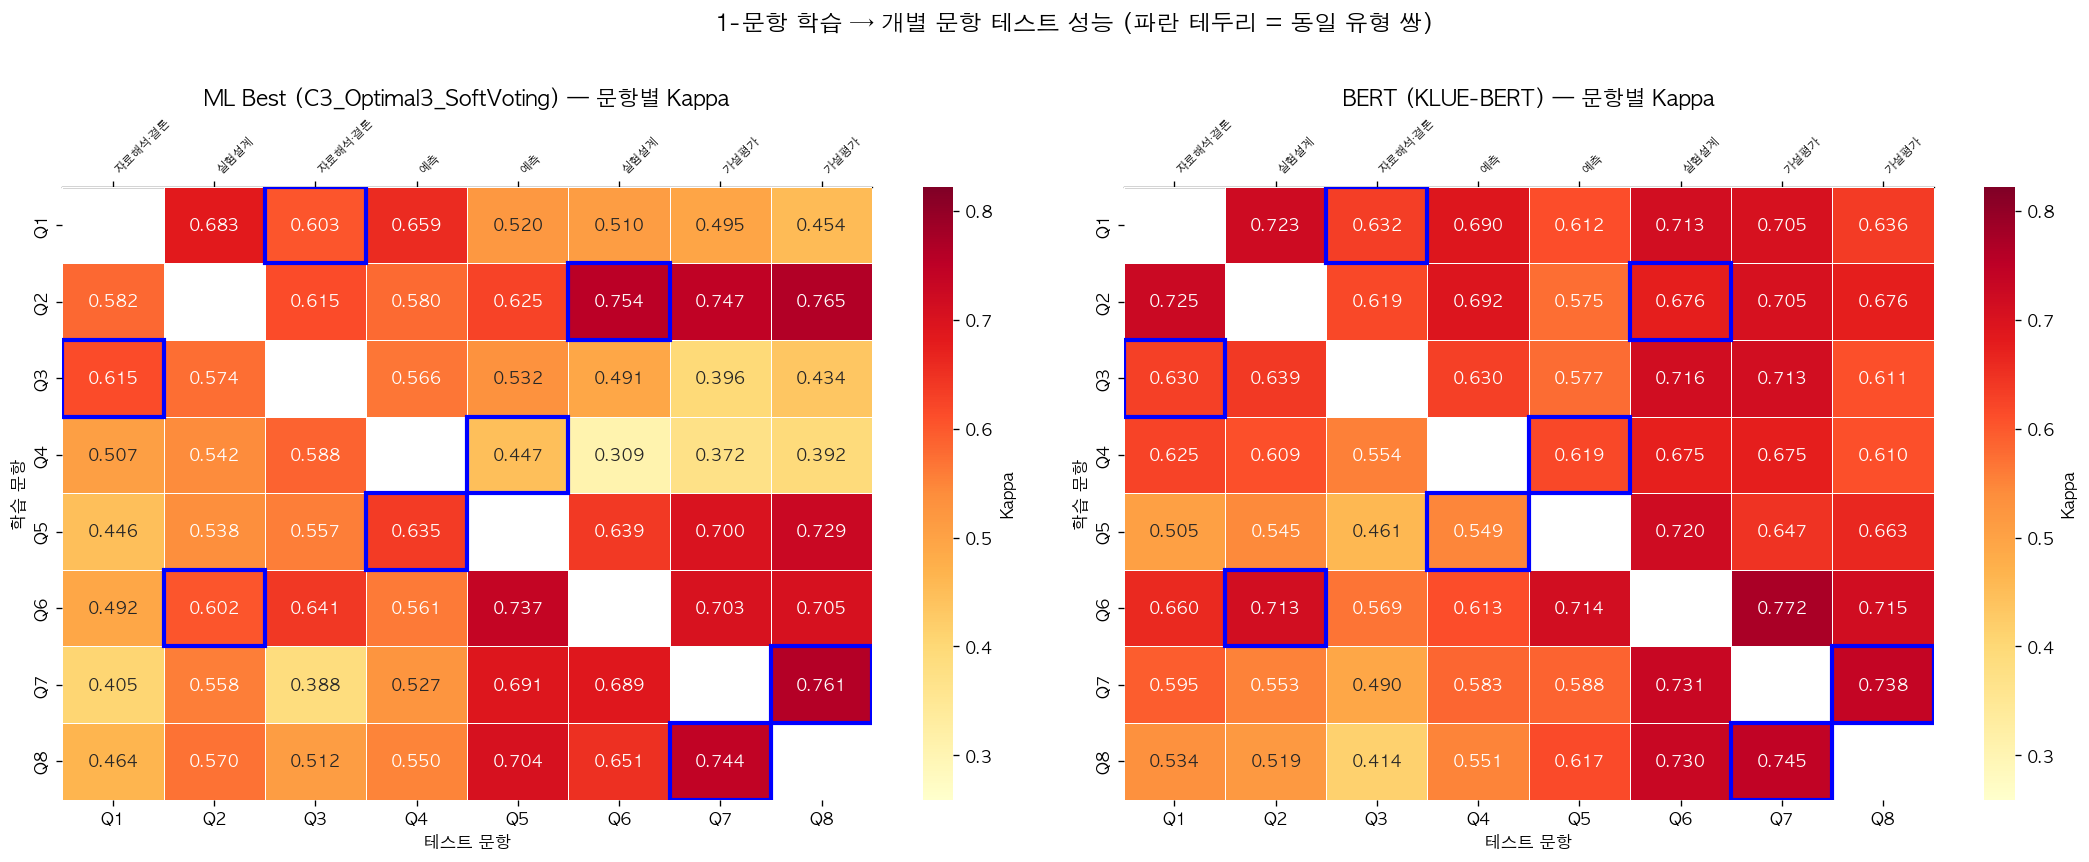

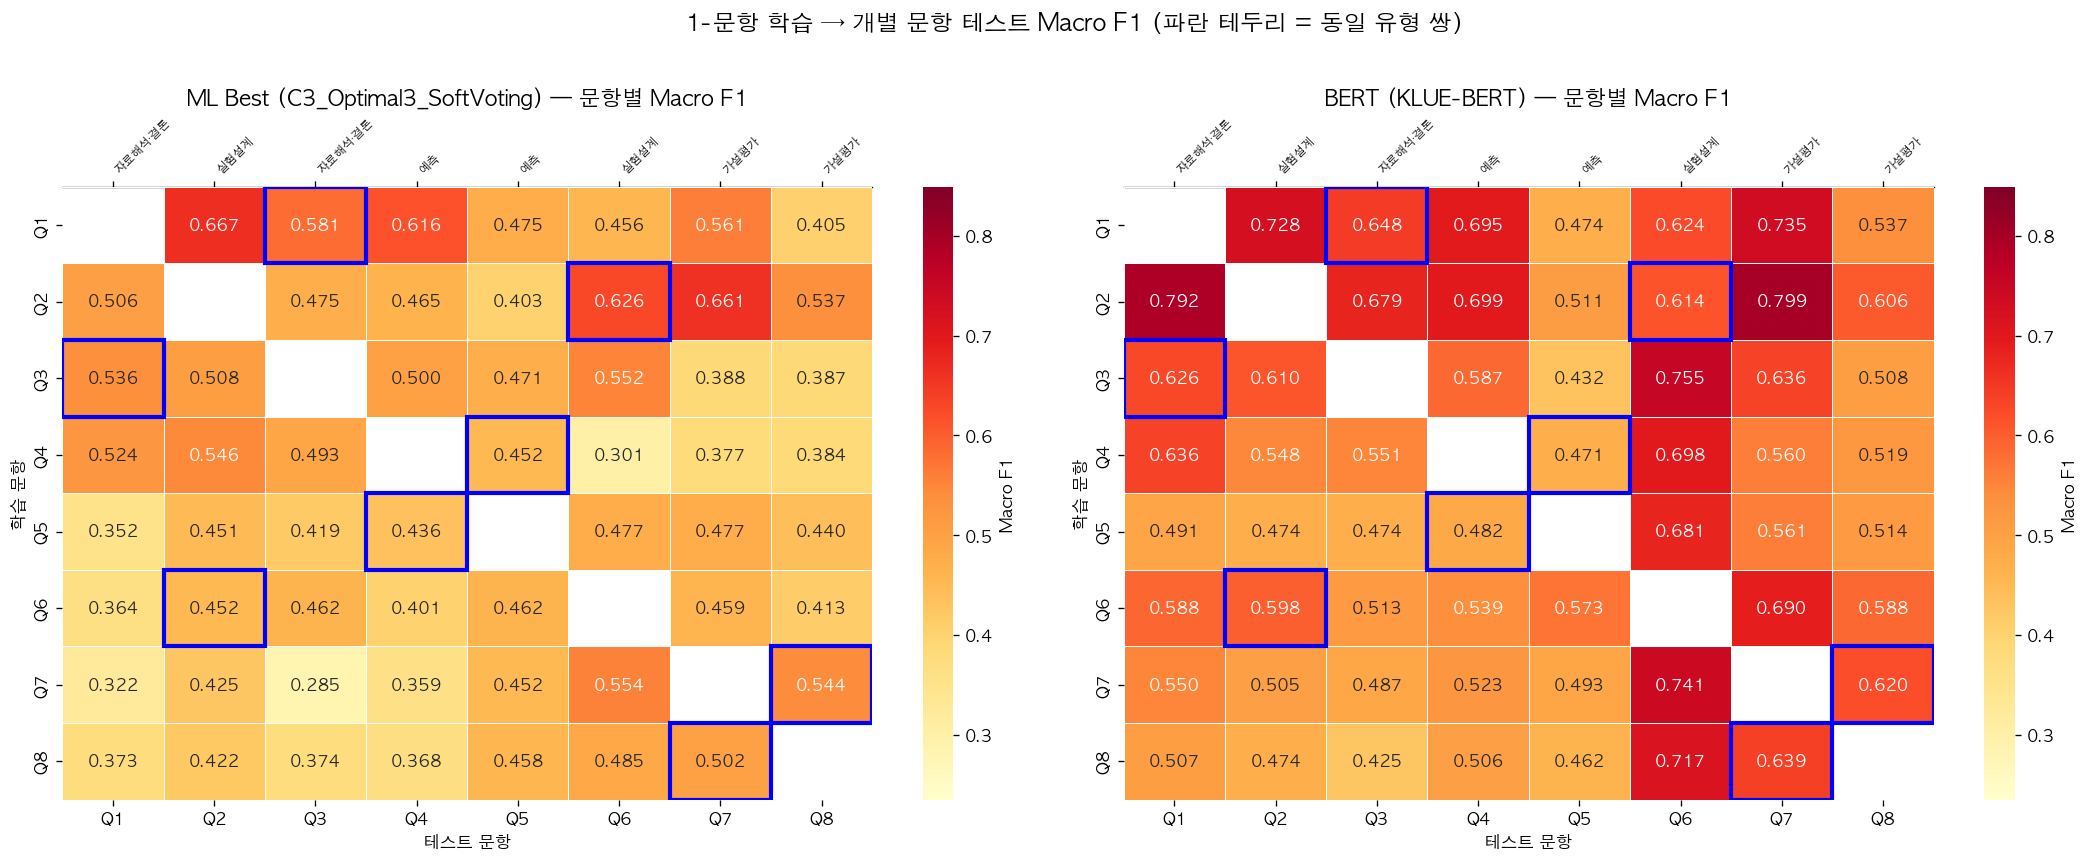

In [7]:
# ══════════════════════════════════════════════════════════════
#  8×8 히트맵 시각화 (BERT & ML Best)
# ══════════════════════════════════════════════════════════════

def plot_heatmap(matrix, title, metric_name='Kappa', ax=None, vmin=None, vmax=None):
    """동일 유형 쌍을 강조 표시한 히트맵"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))

    # 컬러맵 범위
    vals = matrix.values[~np.isnan(matrix.values)]
    if vmin is None:
        vmin = max(0, vals.min() - 0.05)
    if vmax is None:
        vmax = min(1, vals.max() + 0.05)

    sns.heatmap(matrix, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=vmin, vmax=vmax, ax=ax,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': metric_name},
                mask=matrix.isna())

    # 동일 유형 쌍 셀 강조 (파란 테두리)
    for qa, qb in SAME_TYPE_PAIRS:
        r1, c1 = ALL_QUESTIONS.index(qa), ALL_QUESTIONS.index(qb)
        r2, c2 = ALL_QUESTIONS.index(qb), ALL_QUESTIONS.index(qa)
        for r, c in [(r1, c1), (r2, c2)]:
            ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False,
                                       edgecolor='blue', linewidth=2.5))

    ax.set_xlabel('테스트 문항')
    ax.set_ylabel('학습 문항')
    ax.set_title(title, fontsize=13, fontweight='bold')

    # 유형 라벨 추가
    type_labels = [Q_TYPE[q] for q in ALL_QUESTIONS]
    ax2 = ax.secondary_xaxis('top')
    ax2.set_xticks(np.arange(len(ALL_QUESTIONS)) + 0.5)
    ax2.set_xticklabels(type_labels, fontsize=7, rotation=45, ha='left')


# --- Kappa 히트맵 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 공통 스케일
all_vals = np.concatenate([
    bert_matrix_kappa.values[~np.isnan(bert_matrix_kappa.values)],
    ml_best_matrix_kappa.values[~np.isnan(ml_best_matrix_kappa.values)]
])
vmin, vmax = max(0, all_vals.min() - 0.05), min(1, all_vals.max() + 0.05)

plot_heatmap(ml_best_matrix_kappa,
             f'ML Best ({ML_BEST}) — 문항별 Kappa',
             'Kappa', axes[0], vmin, vmax)
plot_heatmap(bert_matrix_kappa,
             'BERT (KLUE-BERT) — 문항별 Kappa',
             'Kappa', axes[1], vmin, vmax)

fig.suptitle('1-문항 학습 → 개별 문항 테스트 성능 (파란 테두리 = 동일 유형 쌍)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- F1 히트맵 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

all_f1 = np.concatenate([
    bert_matrix_f1.values[~np.isnan(bert_matrix_f1.values)],
    ml_best_matrix_f1.values[~np.isnan(ml_best_matrix_f1.values)]
])
vmin_f1, vmax_f1 = max(0, all_f1.min() - 0.05), min(1, all_f1.max() + 0.05)

plot_heatmap(ml_best_matrix_f1,
             f'ML Best ({ML_BEST}) — 문항별 Macro F1',
             'Macro F1', axes[0], vmin_f1, vmax_f1)
plot_heatmap(bert_matrix_f1,
             'BERT (KLUE-BERT) — 문항별 Macro F1',
             'Macro F1', axes[1], vmin_f1, vmax_f1)

fig.suptitle('1-문항 학습 → 개별 문항 테스트 Macro F1 (파란 테두리 = 동일 유형 쌍)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**결과 해석:**

8x8 히트맵(Heatmap)은 모든 문항 쌍 간 전이 성능을 색상으로 나타냅니다. 색이 진할수록 높은 Kappa를 의미합니다.

- **BERT 히트맵**: 전반적으로 ML보다 색이 진하며(높은 Kappa), 특히 Q7-Q8 쌍(가설평가)에서 높은 전이 성능(0.738, 0.755)을 보임 → BERT가 유형 내 전이에서 우수
- **ML 히트맵**: 대각선 근처(동일 유형)가 반드시 가장 높지 않은 경우도 있어, ML은 유형보다 문항 자체의 특성에 더 민감
- **공통 패턴**: Q4(예측)와 Q5(예측)가 학습 문항일 때 전반적으로 낮은 전이 → 예측 유형의 피드백이 학습 데이터로서 효용이 낮음

In [8]:
# ══════════════════════════════════════════════════════════════
#  8×8 매트릭스 수치 테이블 출력
# ══════════════════════════════════════════════════════════════

print('=== BERT — 문항별 Kappa 매트릭스 ===')
display(bert_matrix_kappa.style.format('{:.3f}', na_rep='-')
        .background_gradient(cmap='YlOrRd', vmin=vmin, vmax=vmax))

print(f'\n=== ML Best ({ML_BEST}) — 문항별 Kappa 매트릭스 ===')
display(ml_best_matrix_kappa.style.format('{:.3f}', na_rep='-')
        .background_gradient(cmap='YlOrRd', vmin=vmin, vmax=vmax))

=== BERT — 문항별 Kappa 매트릭스 ===


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8
Q1,-,0.723,0.632,0.690,0.612,0.713,0.705,0.636
Q2,0.725,-,0.619,0.692,0.575,0.676,0.705,0.676
Q3,0.630,0.639,-,0.630,0.577,0.716,0.713,0.611
Q4,0.625,0.609,0.554,-,0.619,0.675,0.675,0.610
Q5,0.505,0.545,0.461,0.549,-,0.720,0.647,0.663
Q6,0.660,0.713,0.569,0.613,0.714,-,0.772,0.715
Q7,0.595,0.553,0.490,0.583,0.588,0.731,-,0.738
Q8,0.534,0.519,0.414,0.551,0.617,0.730,0.745,-



=== ML Best (C3_Optimal3_SoftVoting) — 문항별 Kappa 매트릭스 ===


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8
Q1,-,0.683,0.603,0.659,0.520,0.510,0.495,0.454
Q2,0.582,-,0.615,0.580,0.625,0.754,0.747,0.765
Q3,0.615,0.574,-,0.566,0.532,0.491,0.396,0.434
Q4,0.507,0.542,0.588,-,0.447,0.309,0.372,0.392
Q5,0.446,0.538,0.557,0.635,-,0.639,0.700,0.729
Q6,0.492,0.602,0.641,0.561,0.737,-,0.703,0.705
Q7,0.405,0.558,0.388,0.527,0.691,0.689,-,0.761
Q8,0.464,0.570,0.512,0.550,0.704,0.651,0.744,-


### 8×8 매트릭스 해석 가이드

**수치 테이블 읽기 예시:**
- `BERT 매트릭스에서 Q7 행, Q8 열 = 0.738` → Q7로 학습, Q8을 예측한 Kappa가 0.738
- `Q8 행, Q7 열 = 0.745` → Q8로 학습, Q7을 예측한 Kappa가 0.745
- 이 두 값은 같은 유형 쌍(가설평가)의 **양방향 전이**이며, 차이가 작으면 전이가 대칭적

**주요 관찰 사항:**
- 히트맵에서 **색이 진한(빨간) 셀**일수록 전이 성능이 높음
- 파란 테두리(동일 유형 쌍)가 주변 셀보다 색이 진한지 확인하면 유형 효과를 시각적으로 판단 가능
- 행 간 편차가 크면 → 어떤 문항으로 학습하느냐에 따라 일반화 능력이 크게 달라짐

---
## 3. 분석 2: 동일 유형 vs 다른 유형 전이 성능 비교

### 분석 논리
각 학습 문항(예: Q1)에 대해 테스트 대상 7개 문항을 두 그룹으로 나눔:
- **동일 유형 (1개)**: Q1의 유형 파트너인 Q3 (둘 다 '자료해석·결론')
- **다른 유형 (6개)**: Q2, Q4, Q5, Q6, Q7, Q8 (Q1과 다른 유형의 문항들)

### 테이블 읽는 법
- `동일유형 Kappa`: Q1→Q3의 Kappa (1개 값)
- `→Q2(실험)`, `→Q4(예측)` 등: Q1→해당문항의 개별 Kappa (6개 값)
- `다른유형 평균`: 위 6개 값의 평균
- `다른유형 SD`: 위 6개 값의 표준편차 (다른 유형 내 편차가 큰지 확인)
- `Δ (동일-다른평균)`: **양수이면 동일 유형이 더 높음** = 유형 효과 존재

### 해석 포인트
- Δ가 **8개 문항 모두에서 양수**이면 → 유형 효과가 일관됨
- Δ가 음수인 문항이 있으면 → 해당 유형에서는 유형 일치보다 다른 요인이 더 중요
- SD가 크면 → "다른 유형"이라고 해서 균일하게 낮지 않고, 특정 다른 유형이 오히려 잘 될 수 있음

In [9]:
# ══════════════════════════════════════════════════════════════
#  동일 유형 vs 다른 유형 비교 테이블 (개별값 포함)
# ══════════════════════════════════════════════════════════════

def compute_within_vs_cross(matrix, metric_name='Kappa'):
    """
    각 학습 문항에 대해:
    - 동일 유형 테스트 성능 (1개 값)
    - 다른 유형 테스트 성능 (6개 개별값 + 평균 + 표준편차)
    """
    rows = []
    for train_q in ALL_QUESTIONS:
        partner = SAME_TYPE_PARTNER[train_q]
        within = matrix.loc[train_q, partner]

        cross_qs = [q for q in ALL_QUESTIONS
                    if q != train_q and q != partner]
        cross_vals = [matrix.loc[train_q, q] for q in cross_qs]
        cross_mean = np.nanmean(cross_vals)
        cross_std = np.nanstd(cross_vals)

        row = {
            '학습 문항': train_q,
            '유형': Q_TYPE[train_q],
            '동일유형 파트너': partner,
            f'동일유형 {metric_name}': within,
        }
        # 다른 유형 개별값 컬럼 추가
        for q, v in zip(cross_qs, cross_vals):
            row[f'→{q}({Q_TYPE[q][:2]})'] = v
        row[f'다른유형 평균'] = cross_mean
        row[f'다른유형 SD'] = cross_std
        row[f'Δ (동일-다른평균)'] = within - cross_mean
        rows.append(row)
    return pd.DataFrame(rows)


bert_wc = compute_within_vs_cross(bert_matrix_kappa, 'Kappa')
ml_wc = compute_within_vs_cross(ml_best_matrix_kappa, 'Kappa')

# 포맷 지정 (동적으로 컬럼 추출)
fmt = {'동일유형 Kappa': '{:.3f}', '다른유형 평균': '{:.3f}',
       '다른유형 SD': '{:.3f}', 'Δ (동일-다른평균)': '{:+.3f}'}
for col in bert_wc.columns:
    if col.startswith('→'):
        fmt[col] = '{:.3f}'

print('=== BERT: 동일 유형 vs 다른 유형 비교 — 개별값 포함 (Kappa) ===')
display(bert_wc.style.format(fmt, na_rep='-'))

print(f'\n=== ML Best ({ML_BEST}): 동일 유형 vs 다른 유형 비교 — 개별값 포함 (Kappa) ===')
display(ml_wc.style.format(fmt, na_rep='-'))

=== BERT: 동일 유형 vs 다른 유형 비교 — 개별값 포함 (Kappa) ===


,학습 문항,유형,동일유형 파트너,동일유형 Kappa,→Q2(실험),→Q4(예측),→Q5(예측),→Q6(실험),→Q7(가설),→Q8(가설),다른유형 평균,다른유형 SD,Δ (동일-다른평균),→Q1(자료),→Q3(자료)
0,Q1,자료해석·결론,Q3,0.632,0.723,0.690,0.612,0.713,0.705,0.636,0.680,0.041,-0.048,-,-
1,Q2,실험설계,Q6,0.676,-,0.692,0.575,-,0.705,0.676,0.665,0.052,+0.011,0.725,0.619
2,Q3,자료해석·결론,Q1,0.630,0.639,0.630,0.577,0.716,0.713,0.611,0.648,0.051,-0.017,-,-
3,Q4,예측,Q5,0.619,0.609,-,-,0.675,0.675,0.610,0.625,0.042,-0.006,0.625,0.554
4,Q5,예측,Q4,0.549,0.545,-,-,0.720,0.647,0.663,0.590,0.093,-0.041,0.505,0.461
5,Q6,실험설계,Q2,0.713,-,0.613,0.714,-,0.772,0.715,0.674,0.068,+0.039,0.660,0.569
6,Q7,가설평가,Q8,0.738,0.553,0.583,0.588,0.731,-,-,0.590,0.072,+0.148,0.595,0.490
7,Q8,가설평가,Q7,0.745,0.519,0.551,0.617,0.730,-,-,0.561,0.097,+0.184,0.534,0.414



=== ML Best (C3_Optimal3_SoftVoting): 동일 유형 vs 다른 유형 비교 — 개별값 포함 (Kappa) ===


,학습 문항,유형,동일유형 파트너,동일유형 Kappa,→Q2(실험),→Q4(예측),→Q5(예측),→Q6(실험),→Q7(가설),→Q8(가설),다른유형 평균,다른유형 SD,Δ (동일-다른평균),→Q1(자료),→Q3(자료)
0,Q1,자료해석·결론,Q3,0.603,0.683,0.659,0.520,0.510,0.495,0.454,0.553,0.086,+0.050,-,-
1,Q2,실험설계,Q6,0.754,-,0.580,0.625,-,0.747,0.765,0.652,0.075,+0.102,0.582,0.615
2,Q3,자료해석·결론,Q1,0.615,0.574,0.566,0.532,0.491,0.396,0.434,0.499,0.066,+0.116,-,-
3,Q4,예측,Q5,0.447,0.542,-,-,0.309,0.372,0.392,0.452,0.100,-0.004,0.507,0.588
4,Q5,예측,Q4,0.635,0.538,-,-,0.639,0.700,0.729,0.601,0.098,+0.034,0.446,0.557
5,Q6,실험설계,Q2,0.602,-,0.561,0.737,-,0.703,0.705,0.640,0.087,-0.038,0.492,0.641
6,Q7,가설평가,Q8,0.761,0.558,0.527,0.691,0.689,-,-,0.543,0.120,+0.218,0.405,0.388
7,Q8,가설평가,Q7,0.744,0.570,0.550,0.704,0.651,-,-,0.575,0.081,+0.169,0.464,0.512


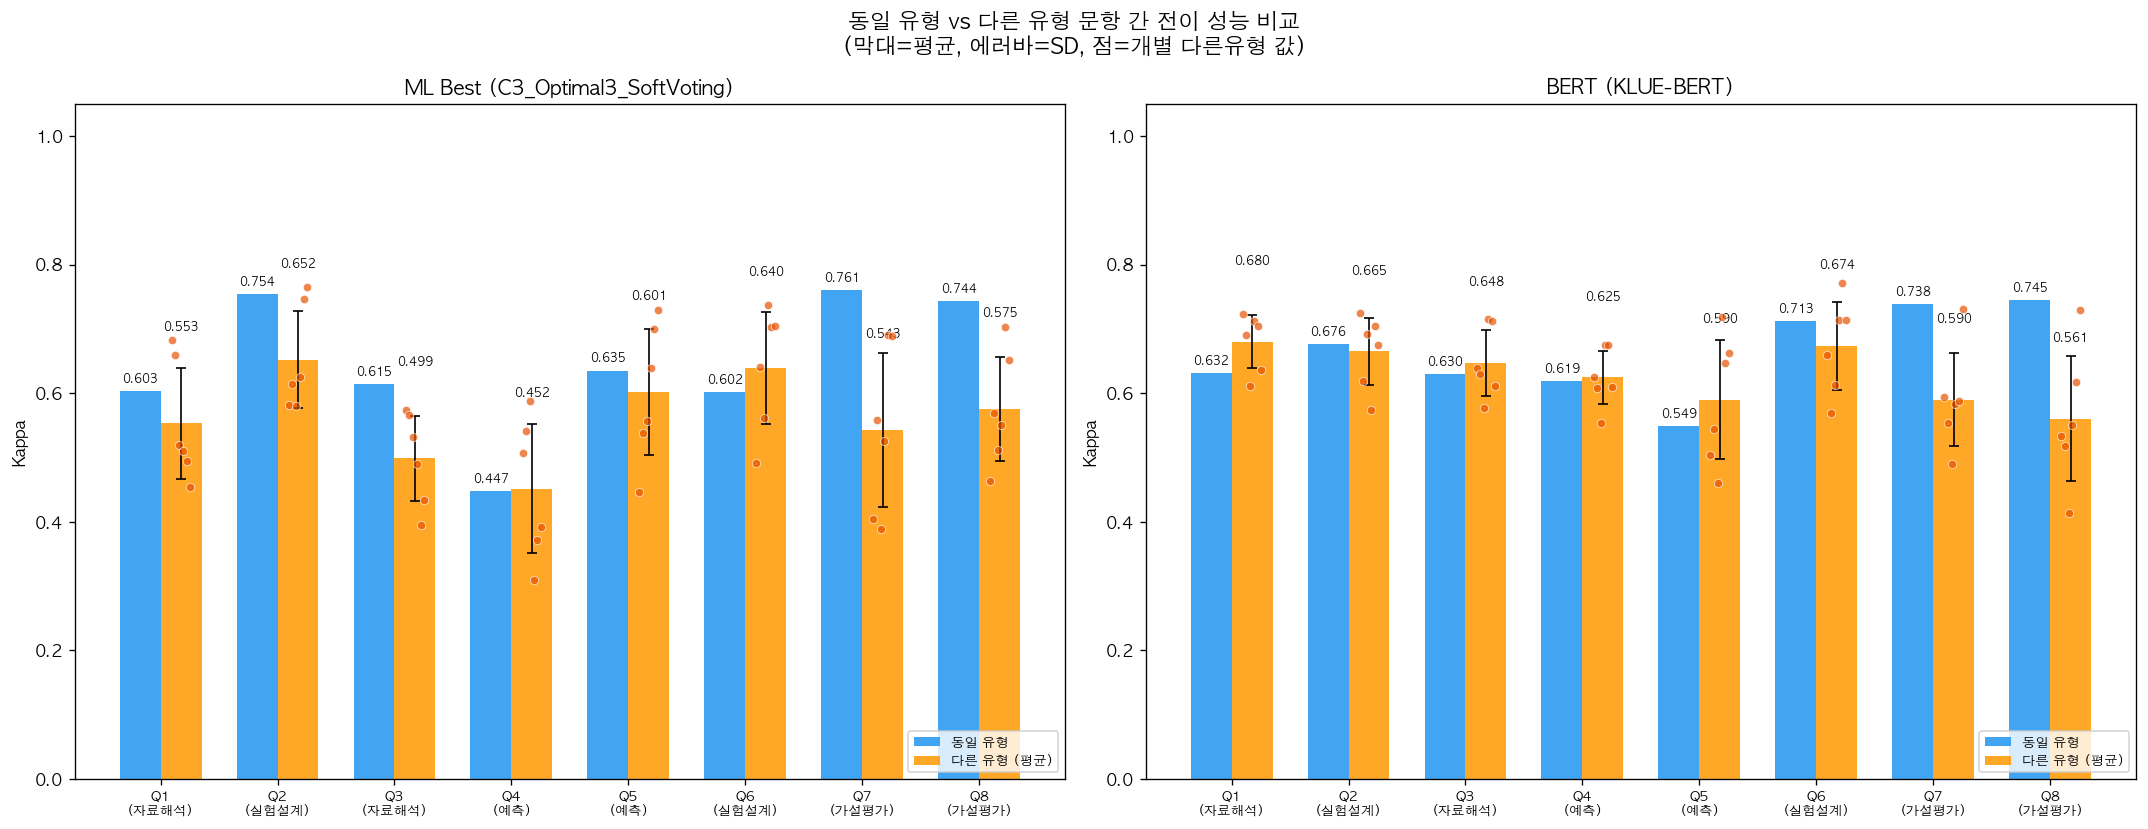

ML Best: 동일유형 평균=0.645, 다른유형 평균=0.564 (평균SD=0.089), Δ=+0.081
BERT: 동일유형 평균=0.663, 다른유형 평균=0.629 (평균SD=0.064), Δ=+0.034


In [10]:
# ══════════════════════════════════════════════════════════════
#  동일 유형 vs 다른 유형 비교 시각화 (개별값 표시)
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, wc_df, matrix, title in [
    (axes[0], ml_wc, ml_best_matrix_kappa, f'ML Best ({ML_BEST})'),
    (axes[1], bert_wc, bert_matrix_kappa, 'BERT (KLUE-BERT)')
]:
    x = np.arange(len(wc_df))
    w = 0.35

    # 동일 유형 막대
    bars1 = ax.bar(x - w/2, wc_df['동일유형 Kappa'], w,
                   label='동일 유형', color='#2196F3', alpha=0.85)

    # 다른 유형 평균 막대 + 에러바
    bars2 = ax.bar(x + w/2, wc_df['다른유형 평균'], w,
                   label='다른 유형 (평균)', color='#FF9800', alpha=0.85,
                   yerr=wc_df['다른유형 SD'], capsize=3, error_kw={'linewidth': 1})

    # 다른 유형 개별값 점으로 표시
    for i, (_, row) in enumerate(wc_df.iterrows()):
        train_q = row['학습 문항']
        partner = row['동일유형 파트너']
        cross_qs = [q for q in ALL_QUESTIONS if q != train_q and q != partner]
        cross_vals = [matrix.loc[train_q, q] for q in cross_qs]

        # 개별 점 (약간의 jitter 추가)
        jitter = np.linspace(-0.08, 0.08, len(cross_vals))
        for j, (cq, cv) in enumerate(zip(cross_qs, cross_vals)):
            ax.scatter(i + w/2 + jitter[j], cv, color='#E65100',
                       s=25, zorder=5, alpha=0.7, edgecolors='white', linewidth=0.5)

    # 값 표시
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + wc_df['다른유형 SD'].max() + 0.02,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{row['학습 문항']}\n({row['유형'][:4]})"
                        for _, row in wc_df.iterrows()], fontsize=8)
    ax.set_ylabel('Kappa')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_ylim(0, 1.05)

fig.suptitle('동일 유형 vs 다른 유형 문항 간 전이 성능 비교\n(막대=평균, 에러바=SD, 점=개별 다른유형 값)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 요약 통계
for label, wc_df in [('ML Best', ml_wc), ('BERT', bert_wc)]:
    within_mean = wc_df['동일유형 Kappa'].mean()
    cross_mean = wc_df['다른유형 평균'].mean()
    cross_sd = wc_df['다른유형 SD'].mean()
    delta_mean = wc_df['Δ (동일-다른평균)'].mean()
    print(f'{label}: 동일유형 평균={within_mean:.3f}, '
          f'다른유형 평균={cross_mean:.3f} (평균SD={cross_sd:.3f}), '
          f'Δ={delta_mean:+.3f}')

**결과 해석:**

동일 유형 vs 다른 유형 전이 비교 막대 차트입니다.

- **파란 막대(동일 유형)**: 같은 유형의 파트너 문항에 대한 Kappa (고정 1개 값)
- **주황 막대(다른 유형)**: 나머지 6개 다른 유형 문항의 평균 Kappa
- **회색 점**: 다른 유형 6개 문항 각각의 개별 Kappa값
- **핵심 발견**: 동일 유형 전이가 항상 다른 유형 전이보다 높지 않음 → 문항 유형보다 문항 자체의 특성(어휘, 맥락)이 전이 성능에 더 큰 영향을 미침
- **시사점**: 단순히 같은 유형의 문항을 추가하는 것보다 다양한 유형을 포함하는 것이 일반화에 유리할 수 있음

### 시각화 해석 가이드

**막대 그래프:**
- **파란 막대** = 동일 유형 파트너 1개 문항에 대한 Kappa (고정된 1개 값)
- **주황 막대** = 다른 유형 6개 문항의 **평균** Kappa
- **에러바** = 다른 유형 6개 값의 표준편차 (분산이 클수록 에러바가 김)
- **주황색 점** = 다른 유형 6개 문항의 **개별 값** (평균이 아닌 실제 분포 확인 가능)

**해석:**
- 파란 막대가 주황 막대보다 높으면 → 해당 학습 문항에서 동일 유형 전이 우위
- 주황색 점들 중 파란 막대보다 높은 것이 있으면 → 동일 유형보다 더 잘 전이되는 다른 유형 문항 존재
- 에러바가 크면 → 다른 유형 문항 간에도 전이 성능 편차가 큼 (유형 외 다른 요인도 작용)

In [11]:
# ══════════════════════════════════════════════════════════════
#  방향성 전이 대칭성 분석
# ══════════════════════════════════════════════════════════════

print('=== 동일 유형 쌍 양방향 전이 대칭성 ===')
print(f'{"":<12} {"":>20} {"":>20}')
print(f'{"유형":<12} {"BERT":>20} {"ML Best":>20}')
print('─' * 55)

for qa, qb in SAME_TYPE_PAIRS:
    q_type = Q_TYPE[qa]
    # BERT
    b_ab = bert_matrix_kappa.loc[qa, qb]
    b_ba = bert_matrix_kappa.loc[qb, qa]
    # ML Best
    m_ab = ml_best_matrix_kappa.loc[qa, qb]
    m_ba = ml_best_matrix_kappa.loc[qb, qa]

    print(f'{q_type:<12} '
          f'{qa}→{qb}: {b_ab:.3f}  {qb}→{qa}: {b_ba:.3f} | '
          f'{qa}→{qb}: {m_ab:.3f}  {qb}→{qa}: {m_ba:.3f}')
    print(f'{"":<12} '
          f'Δ방향: {abs(b_ab - b_ba):.3f}{"":>13} | '
          f'Δ방향: {abs(m_ab - m_ba):.3f}')

=== 동일 유형 쌍 양방향 전이 대칭성 ===
                                                      
유형                           BERT              ML Best
───────────────────────────────────────────────────────
자료해석·결론      Q1→Q3: 0.632  Q3→Q1: 0.630 | Q1→Q3: 0.603  Q3→Q1: 0.615
             Δ방향: 0.001              | Δ방향: 0.012
실험설계         Q2→Q6: 0.676  Q6→Q2: 0.713 | Q2→Q6: 0.754  Q6→Q2: 0.602
             Δ방향: 0.037              | Δ방향: 0.152
예측           Q4→Q5: 0.619  Q5→Q4: 0.549 | Q4→Q5: 0.447  Q5→Q4: 0.635
             Δ방향: 0.070              | Δ방향: 0.188
가설평가         Q7→Q8: 0.738  Q8→Q7: 0.745 | Q7→Q8: 0.761  Q8→Q7: 0.744
             Δ방향: 0.006              | Δ방향: 0.017


### 방향성 전이 대칭성 해석

**대칭성이란?** 같은 유형 쌍(예: Q1↔Q3)에서 양방향 전이가 비슷한지 확인:
- Q1→Q3 (Q1으로 학습, Q3 예측) vs Q3→Q1 (Q3으로 학습, Q1 예측)
- **Δ방향이 작을수록** 양방향 전이가 대칭적 → 두 문항의 피드백 패턴이 유사
- **Δ방향이 크면** 한쪽 문항의 데이터가 상대 문항을 더 잘 설명 → 비대칭적 관계

**BERT vs ML 비교:**
- BERT의 Δ방향이 ML보다 전반적으로 작으면 → BERT가 문항 간 공통 표현을 더 잘 학습
- ML에서 특정 쌍의 Δ방향이 크면 → 해당 문항의 TF-IDF 특성이 방향에 따라 비대칭적

---
## 4. 분석 3: 동일 유형 2-문항 쌍 학습 효과

### 분석 논리
이전 분석에서는 1개 문항으로 학습했을 때의 전이를 봤다면, 여기서는:
- **동일 유형 2개 문항을 함께 학습** (예: Q1+Q3 = 자료해석 2개 문항 모두 사용)
- 나머지 6개 문항에 대한 예측 성능을 측정
- 1-문항 개별 학습(Q1만, Q3만)의 평균 성능과 비교

### 핵심 질문
> 같은 유형 문항 2개를 함께 학습하면, 개별 학습 대비 다른 유형 문항 예측이 향상되는가?

### 테이블 읽는 법
- **요약 테이블**: 유형별로 1-문항 평균 vs 2-문항 성능 비교
  - : 양수이면 2-문항 학습이 더 효과적
  - : 상대적 향상 비율
- **문항별 상세 테이블**: 각 테스트 문항에 대해 1Q(개별) vs 2Q(쌍) 성능 개별 비교
  - : Q1만으로 학습했을 때 해당 테스트 문항 Kappa
  - : Q3만으로 학습했을 때 해당 테스트 문항 Kappa
  - : Q1+Q3 함께 학습했을 때 해당 테스트 문항 Kappa
  - : 2Q가 두 개별 1Q의 평균보다 높은지

In [12]:
# ══════════════════════════════════════════════════════════════
#  동일 유형 2-문항 쌍 학습 → 나머지 6문항 성능
#  vs 1-문항 학습 성능 비교
# ══════════════════════════════════════════════════════════════

def compute_2q_metrics(preds_dict_2q, model_col=None):
    """2-문항 동일유형 쌍 학습의 문항별 성능 산출"""
    results = []
    for combo, df in preds_dict_2q.items():
        pred_col = model_col if model_col else 'predicted_label'
        train_qs = combo.split('_')
        q_type = Q_TYPE[train_qs[0]]

        # 문항별 성능
        for test_q in sorted(df['question'].unique()):
            sub = df[df['question'] == test_q]
            m = compute_metrics(sub['true_label'], sub[pred_col])
            results.append({
                'Train_Combo': combo,
                'Train_Type': q_type,
                'Test_Q': test_q,
                'Test_Type': Q_TYPE[test_q],
                'Same_Type': (Q_TYPE[test_q] == q_type),
                **{f'2Q_{k}': v for k, v in m.items()}
            })
    return pd.DataFrame(results)


bert_2q = compute_2q_metrics(bert_preds_2q)
ml_2q = compute_2q_metrics(ml_preds_2q, model_col=get_pred_col(ML_BEST))

print('=== 2-문항 동일유형 쌍 학습 성능 (BERT) ===')
display(bert_2q.pivot_table(
    index='Train_Combo', columns='Test_Q', values='2Q_Kappa'
).style.format('{:.3f}').background_gradient(cmap='YlOrRd', axis=None))

print(f'\n=== 2-문항 동일유형 쌍 학습 성능 (ML Best: {ML_BEST}) ===')
display(ml_2q.pivot_table(
    index='Train_Combo', columns='Test_Q', values='2Q_Kappa'
).style.format('{:.3f}').background_gradient(cmap='YlOrRd', axis=None))

=== 2-문항 동일유형 쌍 학습 성능 (BERT) ===


Test_Q,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8
Train_Combo,,,,,,,,
Q1_Q3,nan,0.771,nan,0.731,0.691,0.815,0.835,0.736
Q2_Q6,0.796,nan,0.774,0.738,0.694,nan,0.882,0.795
Q4_Q5,0.735,0.757,0.702,nan,nan,0.870,0.839,0.764
Q7_Q8,0.702,0.715,0.619,0.613,0.678,0.785,nan,nan



=== 2-문항 동일유형 쌍 학습 성능 (ML Best: C3_Optimal3_SoftVoting) ===


Test_Q,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8
Train_Combo,,,,,,,,
Q1_Q3,nan,0.673,nan,0.667,0.535,0.532,0.506,0.498
Q2_Q6,0.561,nan,0.693,0.630,0.661,nan,0.718,0.746
Q4_Q5,0.502,0.597,0.589,nan,nan,0.665,0.711,0.754
Q7_Q8,0.472,0.583,0.522,0.529,0.702,0.733,nan,nan


In [13]:
# ══════════════════════════════════════════════════════════════
#  1-문항 학습 vs 2-문항 동일유형 학습 성능 향상 비교 (문항별 개별값)
# ══════════════════════════════════════════════════════════════

def compare_1q_vs_2q_detail(matrix_1q, df_2q, model_label):
    """1-문항 학습과 2-문항 동일유형 학습의 문항별 개별 성능 비교"""
    summary_rows = []
    detail_rows = []

    for qa, qb in SAME_TYPE_PAIRS:
        combo = f'{qa}_{qb}'
        q_type = Q_TYPE[qa]
        test_qs = [q for q in ALL_QUESTIONS if q != qa and q != qb]

        # 문항별 개별 비교
        for tq in test_qs:
            # 1-문항: qa, qb 각각에서 tq로의 성능
            val_1q_a = matrix_1q.loc[qa, tq]
            val_1q_b = matrix_1q.loc[qb, tq]
            avg_1q = (val_1q_a + val_1q_b) / 2

            # 2-문항: combo에서 tq로의 성능
            sub_2q = df_2q[(df_2q['Train_Combo'] == combo) & (df_2q['Test_Q'] == tq)]
            val_2q = sub_2q['2Q_Kappa'].values[0] if len(sub_2q) > 0 else np.nan

            detail_rows.append({
                '유형': q_type,
                '쌍': combo,
                '테스트 문항': tq,
                '테스트 유형': Q_TYPE[tq],
                f'1Q({qa}) Kappa': val_1q_a,
                f'1Q({qb}) Kappa': val_1q_b,
                '1Q 평균 Kappa': avg_1q,
                '2Q Kappa': val_2q,
                'Δ (2Q-1Q평균)': val_2q - avg_1q,
            })

        # 요약 행
        avg_1q_a = np.nanmean([matrix_1q.loc[qa, tq] for tq in test_qs])
        avg_1q_b = np.nanmean([matrix_1q.loc[qb, tq] for tq in test_qs])
        avg_1q = (avg_1q_a + avg_1q_b) / 2
        sub_2q_all = df_2q[df_2q['Train_Combo'] == combo]
        avg_2q = sub_2q_all['2Q_Kappa'].mean()

        summary_rows.append({
            '유형': q_type, '쌍': combo,
            '1-문항 평균 Kappa': avg_1q,
            '2-문항(동일유형) 평균 Kappa': avg_2q,
            'Δ (2Q - 1Q)': avg_2q - avg_1q,
            '향상율(%)': (avg_2q - avg_1q) / avg_1q * 100 if avg_1q > 0 else np.nan
        })

    return pd.DataFrame(summary_rows), pd.DataFrame(detail_rows)


bert_comp, bert_comp_detail = compare_1q_vs_2q_detail(bert_matrix_kappa, bert_2q, 'BERT')
ml_comp, ml_comp_detail = compare_1q_vs_2q_detail(ml_best_matrix_kappa, ml_2q, ML_BEST)

# --- 요약 테이블 ---
print('=== BERT: 1-문항 vs 2-문항(동일유형) 학습 비교 — 요약 ===')
display(bert_comp.style.format({
    '1-문항 평균 Kappa': '{:.3f}',
    '2-문항(동일유형) 평균 Kappa': '{:.3f}',
    'Δ (2Q - 1Q)': '{:+.3f}',
    '향상율(%)': '{:+.1f}%'
}))

print(f'\n=== ML Best ({ML_BEST}): 1-문항 vs 2-문항(동일유형) 학습 비교 — 요약 ===')
display(ml_comp.style.format({
    '1-문항 평균 Kappa': '{:.3f}',
    '2-문항(동일유형) 평균 Kappa': '{:.3f}',
    'Δ (2Q - 1Q)': '{:+.3f}',
    '향상율(%)': '{:+.1f}%'
}))

# --- 문항별 상세 테이블 ---
detail_fmt = {}
for col in bert_comp_detail.columns:
    if 'Kappa' in col or col.startswith('Δ'):
        detail_fmt[col] = '{:.3f}' if 'Δ' not in col else '{:+.3f}'

print('\n=== BERT: 1-문항 vs 2-문항 — 테스트 문항별 개별값 ===')
display(bert_comp_detail.style.format(detail_fmt, na_rep='-'))

print(f'\n=== ML Best ({ML_BEST}): 1-문항 vs 2-문항 — 테스트 문항별 개별값 ===')
display(ml_comp_detail.style.format(detail_fmt, na_rep='-'))

=== BERT: 1-문항 vs 2-문항(동일유형) 학습 비교 — 요약 ===


,유형,쌍,1-문항 평균 Kappa,2-문항(동일유형) 평균 Kappa,Δ (2Q - 1Q),향상율(%)
0,자료해석·결론,Q1_Q3,0.664,0.763,+0.100,+15.0%
1,실험설계,Q2_Q6,0.670,0.780,+0.110,+16.5%
2,예측,Q4_Q5,0.607,0.778,+0.170,+28.1%
3,가설평가,Q7_Q8,0.576,0.685,+0.110,+19.1%



=== ML Best (C3_Optimal3_SoftVoting): 1-문항 vs 2-문항(동일유형) 학습 비교 — 요약 ===


,유형,쌍,1-문항 평균 Kappa,2-문항(동일유형) 평균 Kappa,Δ (2Q - 1Q),향상율(%)
0,자료해석·결론,Q1_Q3,0.526,0.568,+0.042,+8.1%
1,실험설계,Q2_Q6,0.646,0.668,+0.022,+3.4%
2,예측,Q4_Q5,0.527,0.636,+0.110,+20.9%
3,가설평가,Q7_Q8,0.559,0.590,+0.031,+5.6%



=== BERT: 1-문항 vs 2-문항 — 테스트 문항별 개별값 ===


,유형,쌍,테스트 문항,테스트 유형,1Q(Q1) Kappa,1Q(Q3) Kappa,1Q 평균 Kappa,2Q Kappa,Δ (2Q-1Q평균),1Q(Q2) Kappa,1Q(Q6) Kappa,1Q(Q4) Kappa,1Q(Q5) Kappa,1Q(Q7) Kappa,1Q(Q8) Kappa
0,자료해석·결론,Q1_Q3,Q2,실험설계,0.723,0.639,0.681,0.771,+0.090,-,-,-,-,-,-
1,자료해석·결론,Q1_Q3,Q4,예측,0.690,0.630,0.660,0.731,+0.071,-,-,-,-,-,-
2,자료해석·결론,Q1_Q3,Q5,예측,0.612,0.577,0.594,0.691,+0.097,-,-,-,-,-,-
3,자료해석·결론,Q1_Q3,Q6,실험설계,0.713,0.716,0.714,0.815,+0.101,-,-,-,-,-,-
4,자료해석·결론,Q1_Q3,Q7,가설평가,0.705,0.713,0.709,0.835,+0.126,-,-,-,-,-,-
5,자료해석·결론,Q1_Q3,Q8,가설평가,0.636,0.611,0.624,0.736,+0.113,-,-,-,-,-,-
6,실험설계,Q2_Q6,Q1,자료해석·결론,-,-,0.693,0.796,+0.103,0.725,0.660,-,-,-,-
7,실험설계,Q2_Q6,Q3,자료해석·결론,-,-,0.594,0.774,+0.180,0.619,0.569,-,-,-,-
8,실험설계,Q2_Q6,Q4,예측,-,-,0.653,0.738,+0.085,0.692,0.613,-,-,-,-
9,실험설계,Q2_Q6,Q5,예측,-,-,0.644,0.694,+0.050,0.575,0.714,-,-,-,-



=== ML Best (C3_Optimal3_SoftVoting): 1-문항 vs 2-문항 — 테스트 문항별 개별값 ===


,유형,쌍,테스트 문항,테스트 유형,1Q(Q1) Kappa,1Q(Q3) Kappa,1Q 평균 Kappa,2Q Kappa,Δ (2Q-1Q평균),1Q(Q2) Kappa,1Q(Q6) Kappa,1Q(Q4) Kappa,1Q(Q5) Kappa,1Q(Q7) Kappa,1Q(Q8) Kappa
0,자료해석·결론,Q1_Q3,Q2,실험설계,0.683,0.574,0.629,0.673,+0.044,-,-,-,-,-,-
1,자료해석·결론,Q1_Q3,Q4,예측,0.659,0.566,0.613,0.667,+0.054,-,-,-,-,-,-
2,자료해석·결론,Q1_Q3,Q5,예측,0.520,0.532,0.526,0.535,+0.009,-,-,-,-,-,-
3,자료해석·결론,Q1_Q3,Q6,실험설계,0.510,0.491,0.500,0.532,+0.031,-,-,-,-,-,-
4,자료해석·결론,Q1_Q3,Q7,가설평가,0.495,0.396,0.445,0.506,+0.061,-,-,-,-,-,-
5,자료해석·결론,Q1_Q3,Q8,가설평가,0.454,0.434,0.444,0.498,+0.054,-,-,-,-,-,-
6,실험설계,Q2_Q6,Q1,자료해석·결론,-,-,0.537,0.561,+0.024,0.582,0.492,-,-,-,-
7,실험설계,Q2_Q6,Q3,자료해석·결론,-,-,0.628,0.693,+0.065,0.615,0.641,-,-,-,-
8,실험설계,Q2_Q6,Q4,예측,-,-,0.571,0.630,+0.059,0.580,0.561,-,-,-,-
9,실험설계,Q2_Q6,Q5,예측,-,-,0.681,0.661,-0.020,0.625,0.737,-,-,-,-


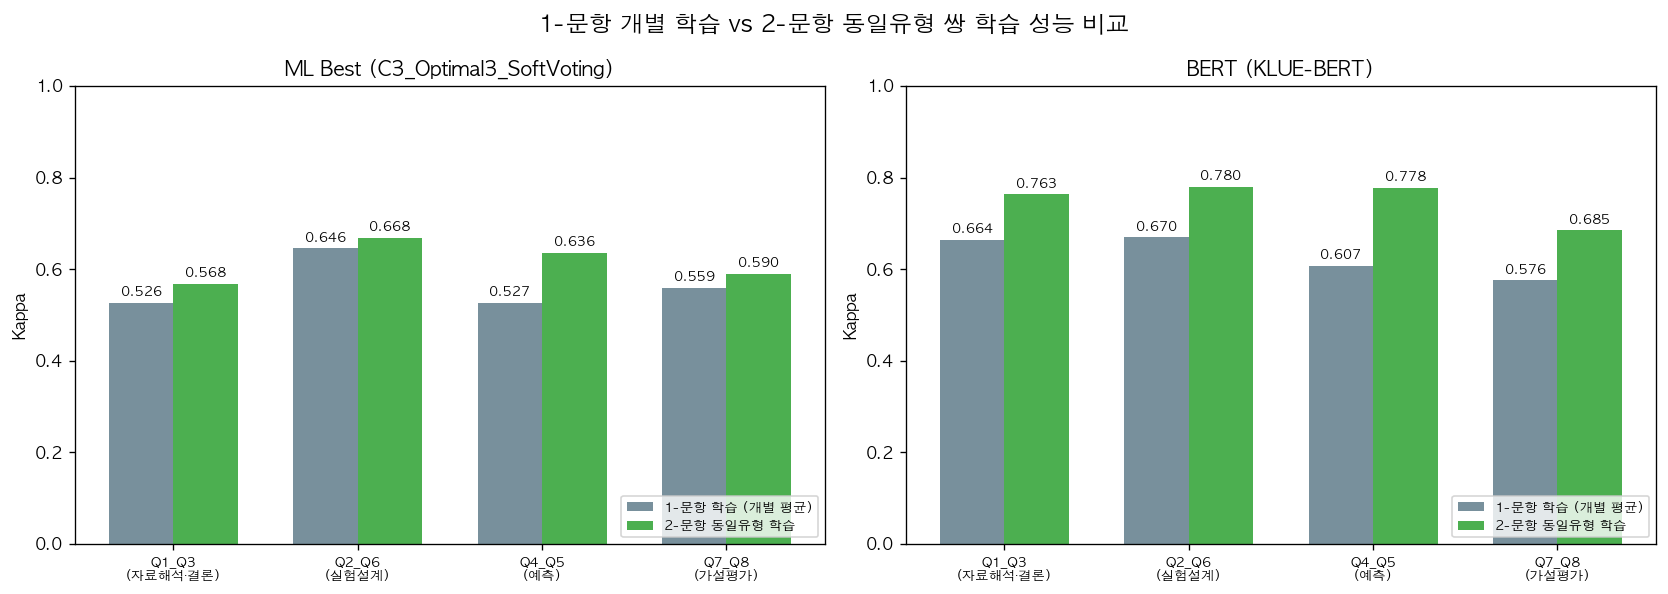

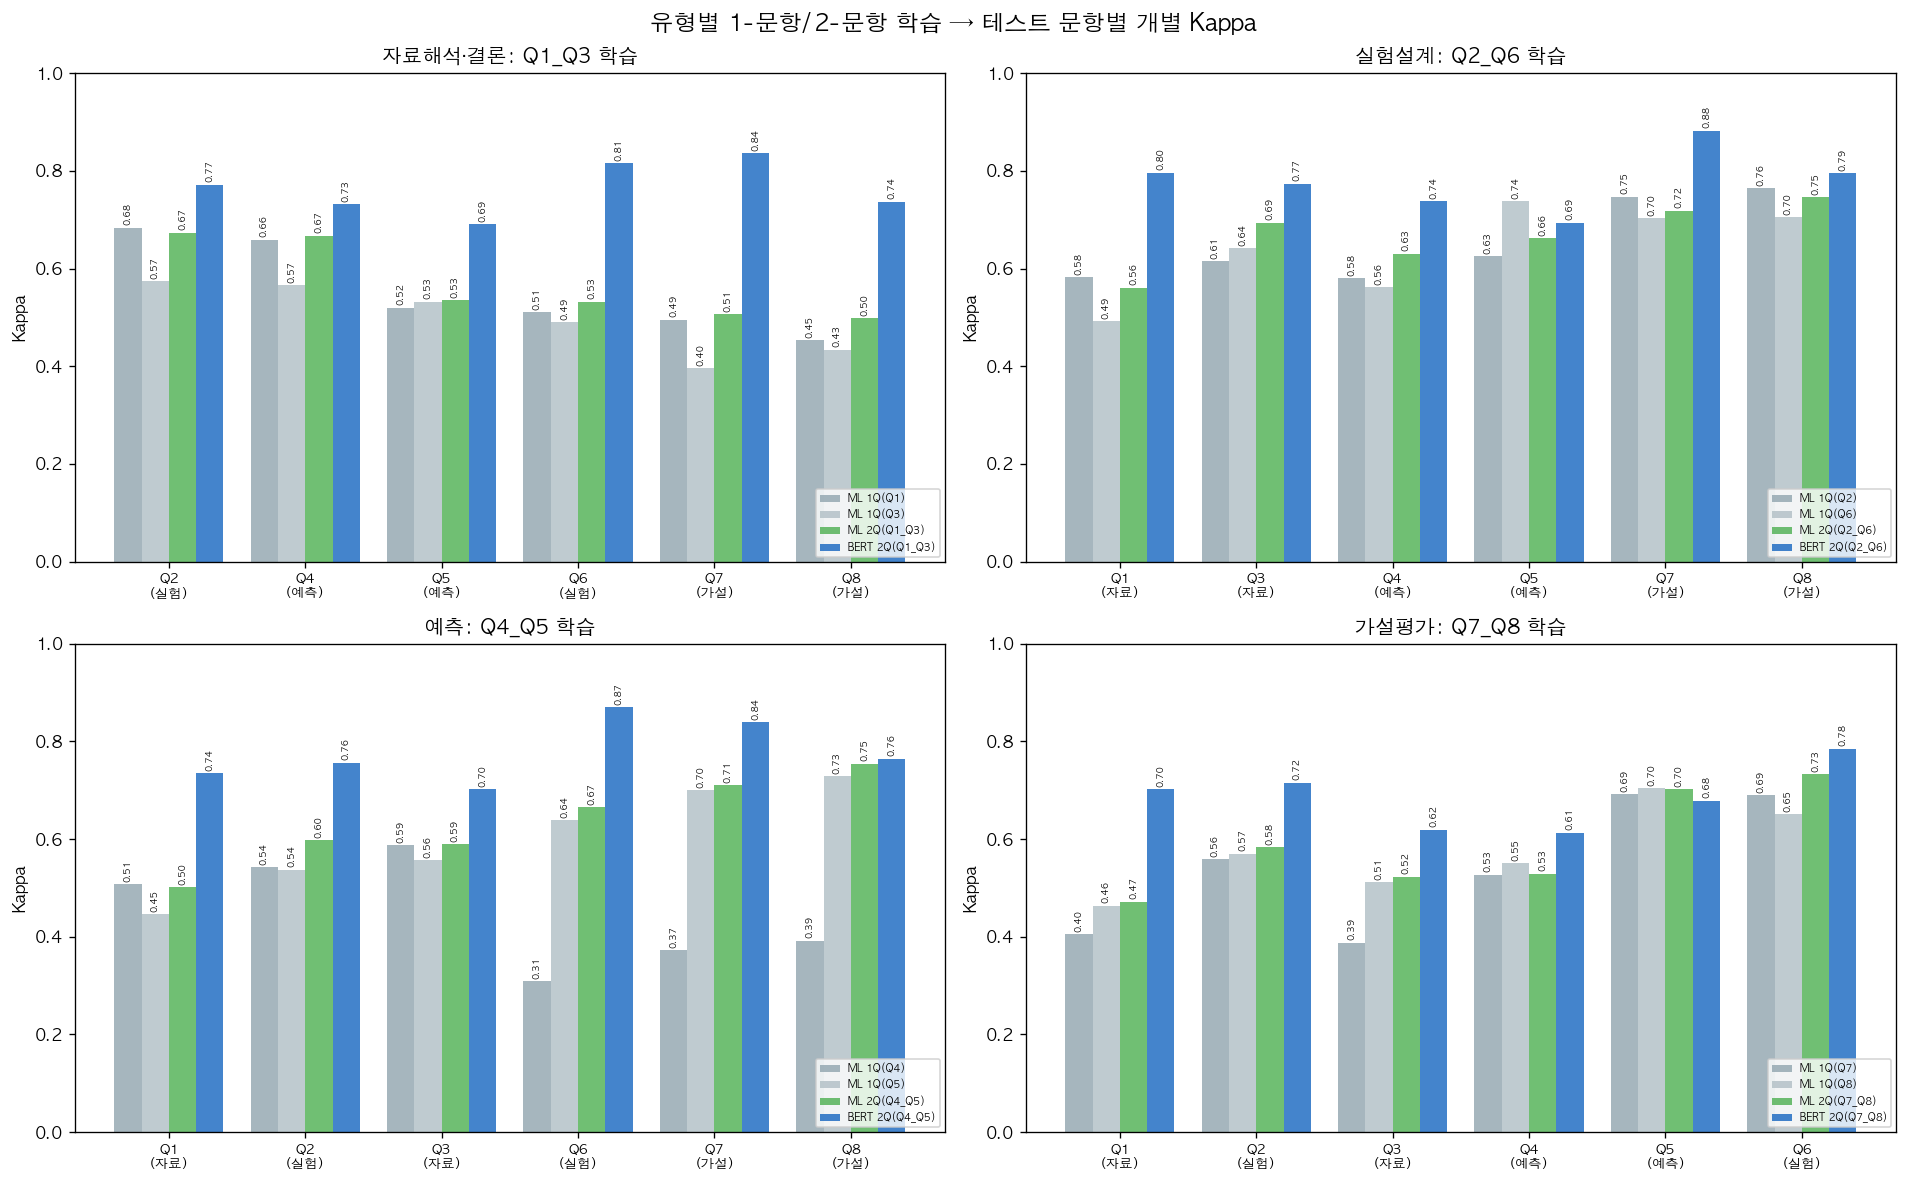

In [14]:
# ══════════════════════════════════════════════════════════════
#  1-문항 vs 2-문항 비교 시각화 (개별 테스트 문항값 포함)
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, comp_df, title in [
    (axes[0], ml_comp, f'ML Best ({ML_BEST})'),
    (axes[1], bert_comp, 'BERT (KLUE-BERT)')
]:
    x = np.arange(len(comp_df))
    w = 0.35

    bars1 = ax.bar(x - w/2, comp_df['1-문항 평균 Kappa'], w,
                   label='1-문항 학습 (개별 평균)', color='#78909C')
    bars2 = ax.bar(x + w/2, comp_df['2-문항(동일유형) 평균 Kappa'], w,
                   label='2-문항 동일유형 학습', color='#4CAF50')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{row['쌍']}\n({row['유형']})" for _, row in comp_df.iterrows()],
                       fontsize=8)
    ax.set_ylabel('Kappa')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_ylim(0, 1.0)

fig.suptitle('1-문항 개별 학습 vs 2-문항 동일유형 쌍 학습 성능 비교',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 문항별 개별값 시각화: 유형별 서브플롯 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, ((qa, qb), ax) in enumerate(zip(SAME_TYPE_PAIRS, axes)):
    combo = f'{qa}_{qb}'
    q_type = Q_TYPE[qa]
    test_qs = [q for q in ALL_QUESTIONS if q != qa and q != qb]

    x = np.arange(len(test_qs))
    w = 0.2

    for label, detail_df, color, offset in [
        (f'ML 1Q({qa})', ml_comp_detail, '#90A4AE', -1.5*w),
        (f'ML 1Q({qb})', ml_comp_detail, '#B0BEC5', -0.5*w),
        (f'ML 2Q({combo})', ml_comp_detail, '#4CAF50', 0.5*w),
        (f'BERT 2Q({combo})', bert_comp_detail, '#1565C0', 1.5*w),
    ]:
        if '1Q' in label and qa in label:
            vals = [ml_best_matrix_kappa.loc[qa, tq] if 'ML' in label
                    else bert_matrix_kappa.loc[qa, tq] for tq in test_qs]
        elif '1Q' in label and qb in label:
            vals = [ml_best_matrix_kappa.loc[qb, tq] if 'ML' in label
                    else bert_matrix_kappa.loc[qb, tq] for tq in test_qs]
        else:
            sub = detail_df[(detail_df['쌍'] == combo)]
            vals = [sub[sub['테스트 문항'] == tq]['2Q Kappa'].values[0]
                    if len(sub[sub['테스트 문항'] == tq]) > 0 else np.nan
                    for tq in test_qs]

        bars = ax.bar(x + offset, vals, w, label=label, color=color, alpha=0.8)
        for bar in bars:
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{bar.get_height():.2f}', ha='center', va='bottom',
                        fontsize=5.5, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{tq}\n({Q_TYPE[tq][:2]})' for tq in test_qs], fontsize=8)
    ax.set_ylabel('Kappa')
    ax.set_title(f'{q_type}: {combo} 학습', fontweight='bold')
    ax.legend(fontsize=6, loc='lower right')
    ax.set_ylim(0, 1.0)

fig.suptitle('유형별 1-문항/2-문항 학습 → 테스트 문항별 개별 Kappa',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. 분석 4: 4×4 유형 수준 전이 매트릭스

### 분석 논리
8개 문항 수준의 결과를 **4개 유형 수준으로 집계**하여 거시적 전이 패턴을 확인한다.
- 각 유형에는 2개 문항이 속하므로, 유형 간 전이값 = 해당 문항 쌍들의 평균
- 예: "자료해석→실험설계" = (Q1→Q2, Q1→Q6, Q3→Q2, Q3→Q6)의 평균 Kappa
- 예: "자료해석→자료해석" = (Q1→Q3, Q3→Q1)의 평균 (동일 유형 내 양방향)

### 4×4 매트릭스 읽는 법
- **행 = 학습 유형**, **열 = 테스트 유형** (8×8과 동일한 방향)
- **대각선(파란 테두리)** = 동일 유형 내 전이 (자료해석→자료해석 등)
- **비대각선** = 다른 유형 간 전이
- 대각선 값이 비대각선보다 체계적으로 높으면 → 유형별 전이 효과 존재

### 해석 포인트
- 대각선 평균 vs 비대각선 평균의 Δ가 핵심 결론 수치
- 특정 유형 쌍의 비대각선 값이 대각선보다 높으면 → 해당 유형 간 전이가 유형 내 전이보다 강함

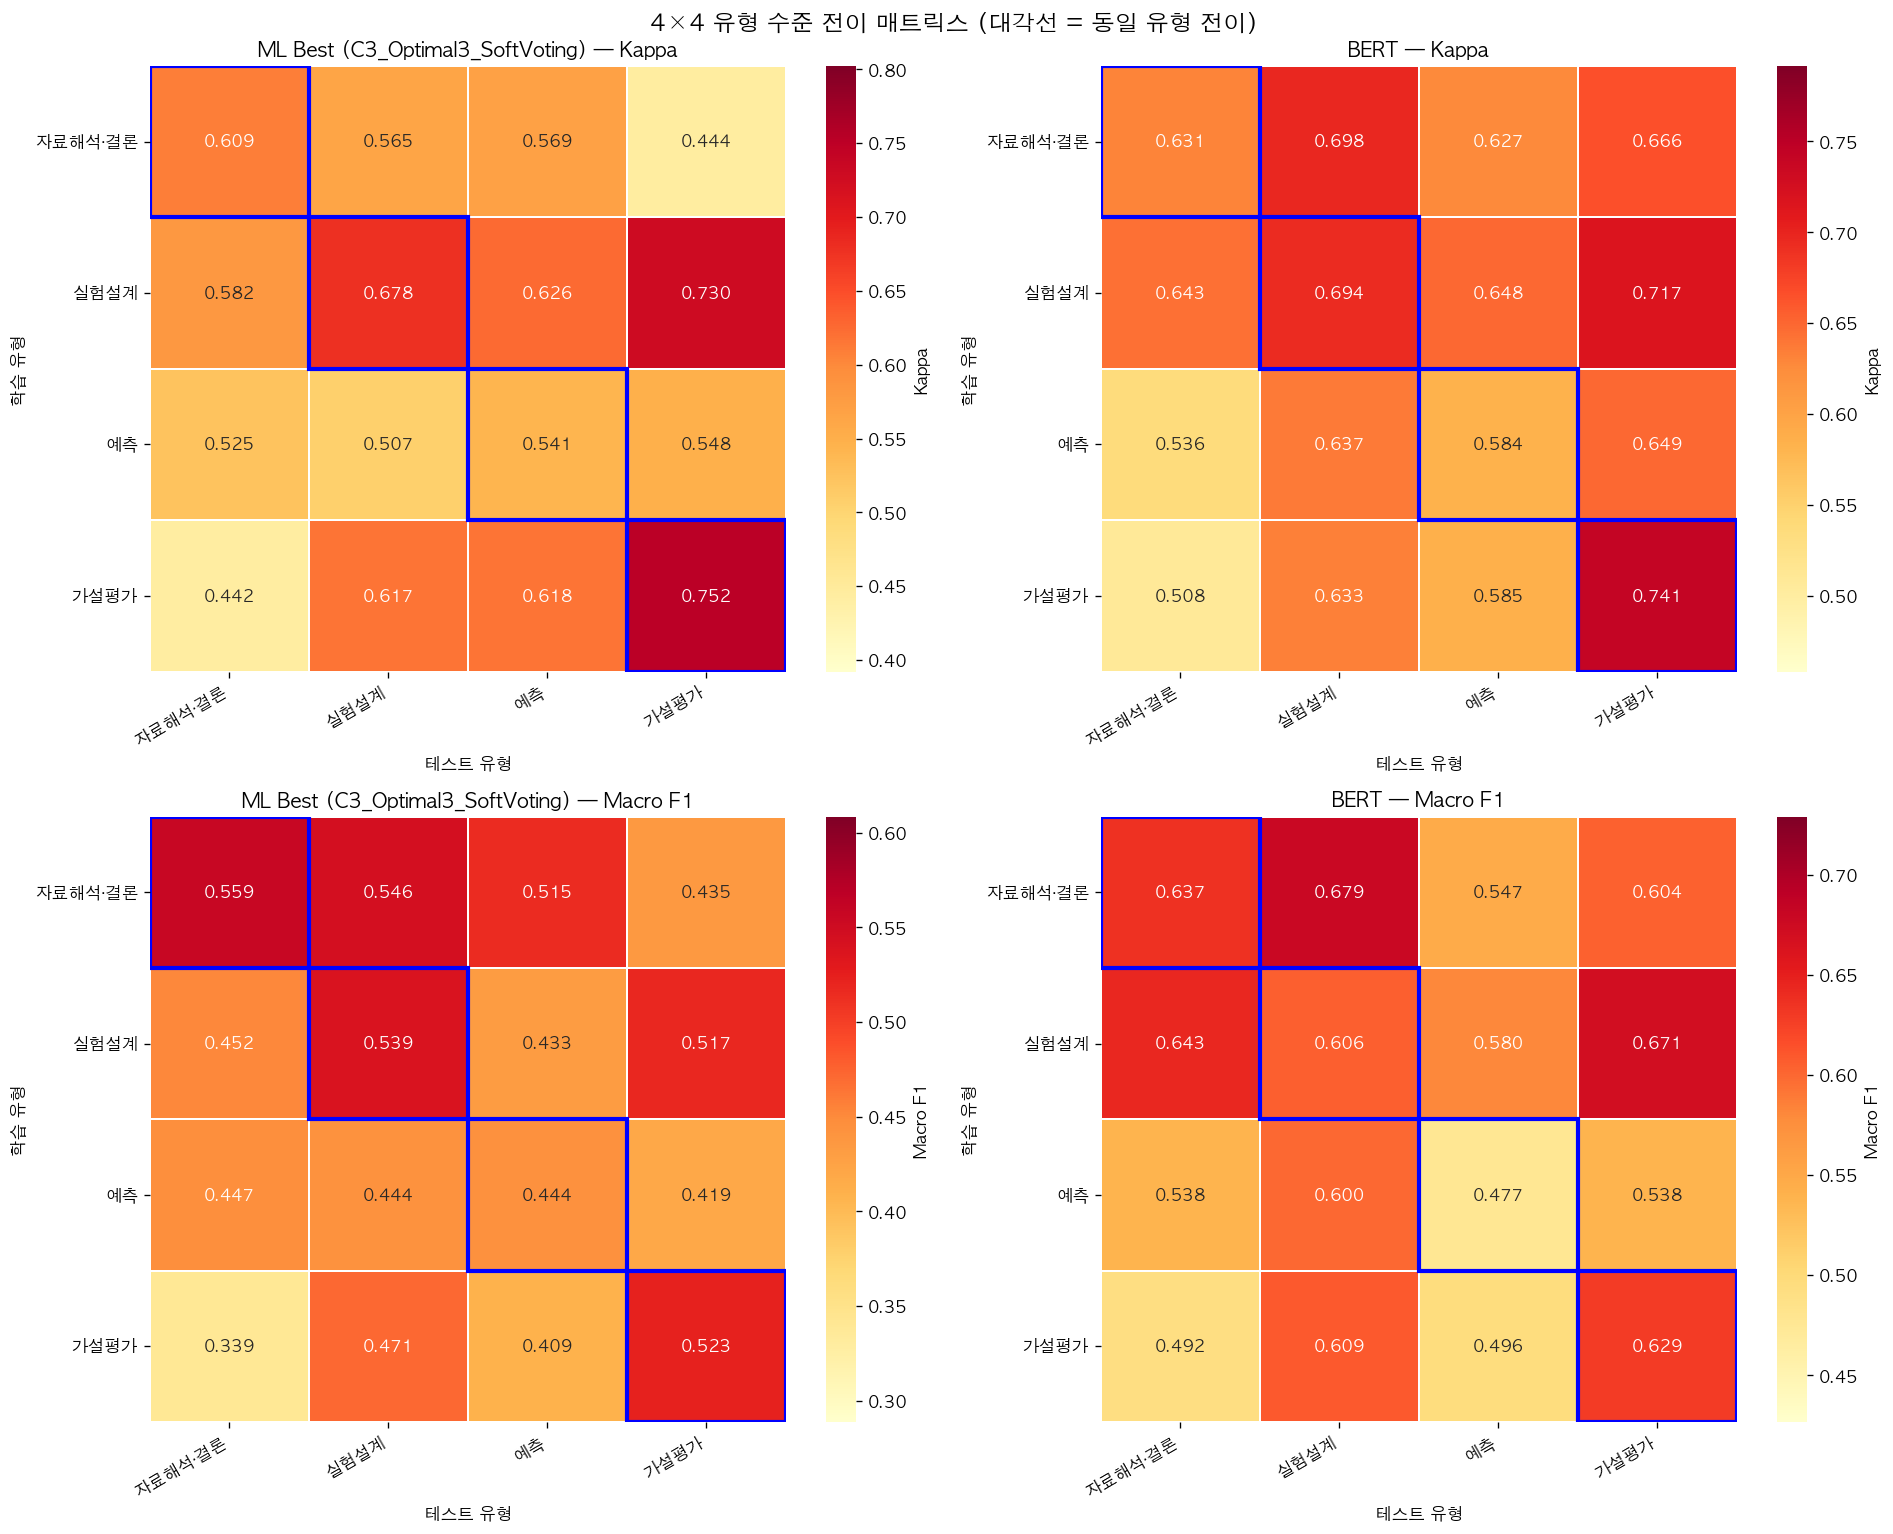

In [15]:
# ══════════════════════════════════════════════════════════════
#  4×4 유형 수준 전이 매트릭스
#  각 유형 내 문항 쌍의 평균으로 집계
# ══════════════════════════════════════════════════════════════

def build_type_matrix(q_matrix, metric_name='Kappa'):
    """
    8×8 문항 매트릭스 → 4×4 유형 매트릭스로 집계.
    각 셀은 해당 유형 간 모든 문항 쌍의 평균.
    """
    type_matrix = pd.DataFrame(np.nan, index=TYPE_NAMES, columns=TYPE_NAMES)

    for train_type in TYPE_NAMES:
        for test_type in TYPE_NAMES:
            train_qs = TYPE_QUESTIONS[train_type]
            test_qs = TYPE_QUESTIONS[test_type]

            vals = []
            for tq in train_qs:
                for teq in test_qs:
                    if tq != teq:  # 자기 자신 제외
                        v = q_matrix.loc[tq, teq]
                        if not np.isnan(v):
                            vals.append(v)

            if vals:
                type_matrix.loc[train_type, test_type] = np.mean(vals)

    return type_matrix


bert_type_kappa = build_type_matrix(bert_matrix_kappa)
ml_type_kappa = build_type_matrix(ml_best_matrix_kappa)
bert_type_f1 = build_type_matrix(bert_matrix_f1)
ml_type_f1 = build_type_matrix(ml_best_matrix_f1)

# 히트맵 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

configs = [
    (axes[0, 0], ml_type_kappa, f'ML Best ({ML_BEST}) — Kappa', 'Kappa'),
    (axes[0, 1], bert_type_kappa, 'BERT — Kappa', 'Kappa'),
    (axes[1, 0], ml_type_f1, f'ML Best ({ML_BEST}) — Macro F1', 'Macro F1'),
    (axes[1, 1], bert_type_f1, 'BERT — Macro F1', 'Macro F1'),
]

for ax, mat, title, cbar_label in configs:
    vals = mat.values[~np.isnan(mat.values)]
    vm, vx = max(0, vals.min() - 0.05), min(1, vals.max() + 0.05)
    sns.heatmap(mat, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=vm, vmax=vx, ax=ax,
                linewidths=1, linecolor='white',
                cbar_kws={'label': cbar_label})

    # 대각선(동일유형) 강조
    for i in range(4):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                   edgecolor='blue', linewidth=2.5))

    ax.set_xlabel('테스트 유형')
    ax.set_ylabel('학습 유형')
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

fig.suptitle('4×4 유형 수준 전이 매트릭스 (대각선 = 동일 유형 전이)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**결과 해석:**

4x4 유형 수준 전이 매트릭스 히트맵입니다. 행은 학습 유형, 열은 테스트 유형이며, 빨간 점선 테두리가 대각선(동일 유형) 셀을 강조합니다.

- **ML 매트릭스**: 가설평가(0.752)가 대각선에서 가장 높고, 예측(0.541)이 가장 낮음 → 가설평가 유형이 ML에서 가장 일반화가 잘 됨
- **BERT 매트릭스**: 가설평가(0.741)가 가장 높고, 전반적으로 ML보다 균일한 성능 → BERT의 전이 학습 능력이 유형 간 격차를 줄임
- **비대각선 주목**: ML에서 실험설계->가설평가(0.730)가 대각선(0.678)보다 높은 "역전 현상" → 유형 간 숨겨진 유사성 존재

In [16]:
# ══════════════════════════════════════════════════════════════
#  4×4 유형 매트릭스 수치 테이블
# ══════════════════════════════════════════════════════════════

print('=== BERT — 4×4 유형 전이 매트릭스 (Kappa) ===')
display(bert_type_kappa.style.format('{:.3f}')
        .background_gradient(cmap='YlOrRd', axis=None))

print(f'\n=== ML Best ({ML_BEST}) — 4×4 유형 전이 매트릭스 (Kappa) ===')
display(ml_type_kappa.style.format('{:.3f}')
        .background_gradient(cmap='YlOrRd', axis=None))

# 대각선 vs 비대각선 요약
for label, mat in [('BERT', bert_type_kappa), (f'ML Best ({ML_BEST})', ml_type_kappa)]:
    diag = np.array([mat.iloc[i, i] for i in range(4)])
    off_diag = mat.values[~np.eye(4, dtype=bool) & ~np.isnan(mat.values)]
    print(f'\n{label}:')
    print(f'  대각선(동일유형) 평균: {np.nanmean(diag):.3f} '
          f'(범위: {np.nanmin(diag):.3f}~{np.nanmax(diag):.3f})')
    print(f'  비대각선(다른유형) 평균: {np.nanmean(off_diag):.3f} '
          f'(범위: {np.nanmin(off_diag):.3f}~{np.nanmax(off_diag):.3f})')
    print(f'  Δ(동일-다른): {np.nanmean(diag) - np.nanmean(off_diag):+.3f}')

=== BERT — 4×4 유형 전이 매트릭스 (Kappa) ===


,자료해석·결론,실험설계,예측,가설평가
자료해석·결론,0.631,0.698,0.627,0.666
실험설계,0.643,0.694,0.648,0.717
예측,0.536,0.637,0.584,0.649
가설평가,0.508,0.633,0.585,0.741



=== ML Best (C3_Optimal3_SoftVoting) — 4×4 유형 전이 매트릭스 (Kappa) ===


,자료해석·결론,실험설계,예측,가설평가
자료해석·결론,0.609,0.565,0.569,0.444
실험설계,0.582,0.678,0.626,0.730
예측,0.525,0.507,0.541,0.548
가설평가,0.442,0.617,0.618,0.752



BERT:
  대각선(동일유형) 평균: 0.663 (범위: 0.584~0.741)
  비대각선(다른유형) 평균: 0.629 (범위: 0.508~0.717)
  Δ(동일-다른): +0.034

ML Best (C3_Optimal3_SoftVoting):
  대각선(동일유형) 평균: 0.645 (범위: 0.541~0.752)
  비대각선(다른유형) 평균: 0.564 (범위: 0.442~0.730)
  Δ(동일-다른): +0.081


---
## 6. 분석 5: ML vs BERT 종합 비교

### 분석 논리
ML(TF-IDF 기반)과 BERT(사전학습 언어모델)가 문항 유형에 따른 전이를 다르게 포착하는지 비교.

### 56개 쌍 비교 읽는 법
- 8×7 = 56개 학습-테스트 쌍 각각에서 ML과 BERT의 Kappa를 직접 비교
- "BERT 우위": BERT Kappa > ML Kappa인 쌍의 비율
- 동일 유형(8쌍)과 다른 유형(48쌍)에서 BERT 우위 비율이 다르면 → 모델별 유형 민감도 차이

### 산점도 해석
- 각 점 = 하나의 학습-테스트 쌍 (총 56개)
- **대각선 위 점**: BERT가 ML보다 높음 / **대각선 아래 점**: ML이 BERT보다 높음
- **파란 다이아몬드** = 동일 유형 쌍, **주황 원** = 다른 유형 쌍
- 다른 유형(주황)이 대각선 위에 더 많으면 → BERT가 특히 다른 유형 전이에서 강점

### 24모델 비교 해석
- ML 24개 모델 각각의 동일/다른 유형 성능을 BERT 기준선과 비교
- BERT 점선보다 ML 막대가 높으면 → 해당 ML 모델이 BERT보다 우수
- 동일 유형(파란)과 다른 유형(주황) 간 격차가 큰 모델 → 유형 민감도가 높은 모델

In [17]:
# ══════════════════════════════════════════════════════════════
#  ML vs BERT: 동일 조건 직접 비교
# ══════════════════════════════════════════════════════════════

# 1) 전체 56개 쌍에서 모델 간 비교
comparison_rows = []
for train_q in ALL_QUESTIONS:
    for test_q in ALL_QUESTIONS:
        if train_q == test_q:
            continue
        same = Q_TYPE[train_q] == Q_TYPE[test_q]
        comparison_rows.append({
            'Train_Q': train_q,
            'Test_Q': test_q,
            'Train_Type': Q_TYPE[train_q],
            'Test_Type': Q_TYPE[test_q],
            'Same_Type': same,
            'ML_Kappa': ml_best_matrix_kappa.loc[train_q, test_q],
            'BERT_Kappa': bert_matrix_kappa.loc[train_q, test_q],
            'ML_F1': ml_best_matrix_f1.loc[train_q, test_q],
            'BERT_F1': bert_matrix_f1.loc[train_q, test_q],
        })

comp_df = pd.DataFrame(comparison_rows)
comp_df['BERT_advantage_Kappa'] = comp_df['BERT_Kappa'] - comp_df['ML_Kappa']
comp_df['BERT_advantage_F1'] = comp_df['BERT_F1'] - comp_df['ML_F1']

# 요약
print('=== ML vs BERT: 56개 학습-테스트 쌍 비교 ===')
for condition, label in [(True, '동일 유형'), (False, '다른 유형')]:
    sub = comp_df[comp_df['Same_Type'] == condition]
    n = len(sub)
    bert_win = (sub['BERT_advantage_Kappa'] > 0).sum()
    print(f'\n{label} ({n}쌍):')
    print(f'  BERT 우위: {bert_win}/{n} ({bert_win/n*100:.0f}%)')
    print(f'  BERT 평균 Kappa: {sub["BERT_Kappa"].mean():.3f}')
    print(f'  ML 평균 Kappa:   {sub["ML_Kappa"].mean():.3f}')
    print(f'  BERT 우위 평균:  {sub["BERT_advantage_Kappa"].mean():+.3f}')

=== ML vs BERT: 56개 학습-테스트 쌍 비교 ===

동일 유형 (8쌍):
  BERT 우위: 5/8 (62%)
  BERT 평균 Kappa: 0.663
  ML 평균 Kappa:   0.645
  BERT 우위 평균:  +0.018

다른 유형 (48쌍):
  BERT 우위: 34/48 (71%)
  BERT 평균 Kappa: 0.629
  ML 평균 Kappa:   0.564
  BERT 우위 평균:  +0.065


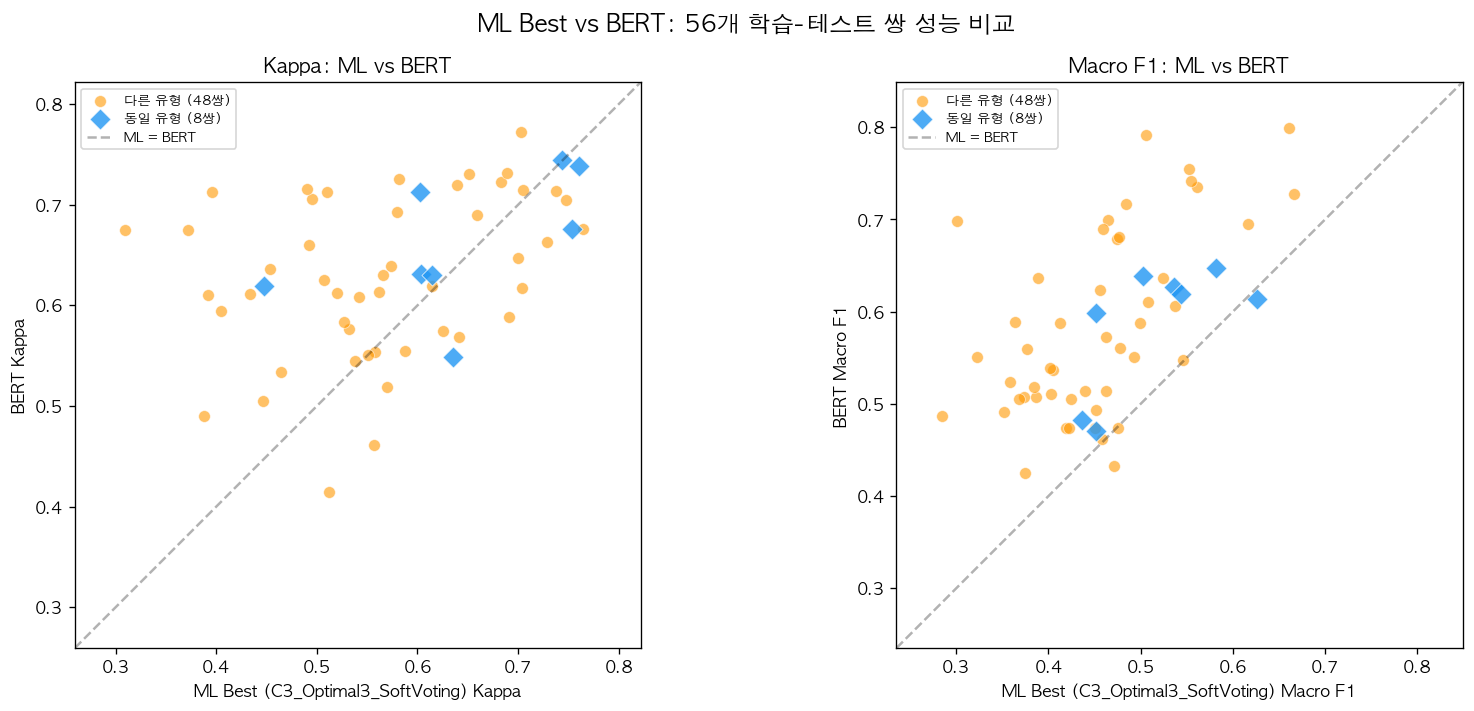

In [18]:
# ══════════════════════════════════════════════════════════════
#  ML vs BERT 산점도 (동일유형 vs 다른유형 구분)
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, mlabel in [
    (axes[0], 'Kappa', 'Kappa'),
    (axes[1], 'F1', 'Macro F1')
]:
    same = comp_df[comp_df['Same_Type']]
    diff = comp_df[~comp_df['Same_Type']]

    ax.scatter(diff[f'ML_{metric}'], diff[f'BERT_{metric}'],
               c='#FF9800', alpha=0.6, s=50, label=f'다른 유형 ({len(diff)}쌍)',
               edgecolors='white', linewidth=0.5)
    ax.scatter(same[f'ML_{metric}'], same[f'BERT_{metric}'],
               c='#2196F3', alpha=0.8, s=80, label=f'동일 유형 ({len(same)}쌍)',
               edgecolors='white', linewidth=0.5, marker='D')

    # 대각선 (ML = BERT)
    lim_min = min(comp_df[f'ML_{metric}'].min(), comp_df[f'BERT_{metric}'].min()) - 0.05
    lim_max = max(comp_df[f'ML_{metric}'].max(), comp_df[f'BERT_{metric}'].max()) + 0.05
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.3, label='ML = BERT')

    ax.set_xlabel(f'ML Best ({ML_BEST}) {mlabel}')
    ax.set_ylabel(f'BERT {mlabel}')
    ax.set_title(f'{mlabel}: ML vs BERT', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_aspect('equal')

fig.suptitle('ML Best vs BERT: 56개 학습-테스트 쌍 성능 비교',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**결과 해석:**

ML vs BERT 산점도(Scatter Plot)입니다. 각 점은 하나의 학습-테스트 문항 쌍을 나타내며, x축이 ML Kappa, y축이 BERT Kappa입니다.

- **대각선 위의 점**: BERT가 ML보다 우수한 경우 (대부분의 점이 여기에 위치)
- **파란 점(동일 유형)**: 동일 유형 전이는 두 접근법 모두에서 상대적으로 높은 Kappa를 보이는 경향
- **주황 점(다른 유형)**: 다른 유형 전이에서 BERT의 우위가 더 뚜렷 → BERT가 유형 간 전이에서 ML보다 훨씬 강건
- **시사점**: 문항 유형이 다른 상황에서의 일반화가 필요한 교육 현장에서는 BERT가 ML보다 적합

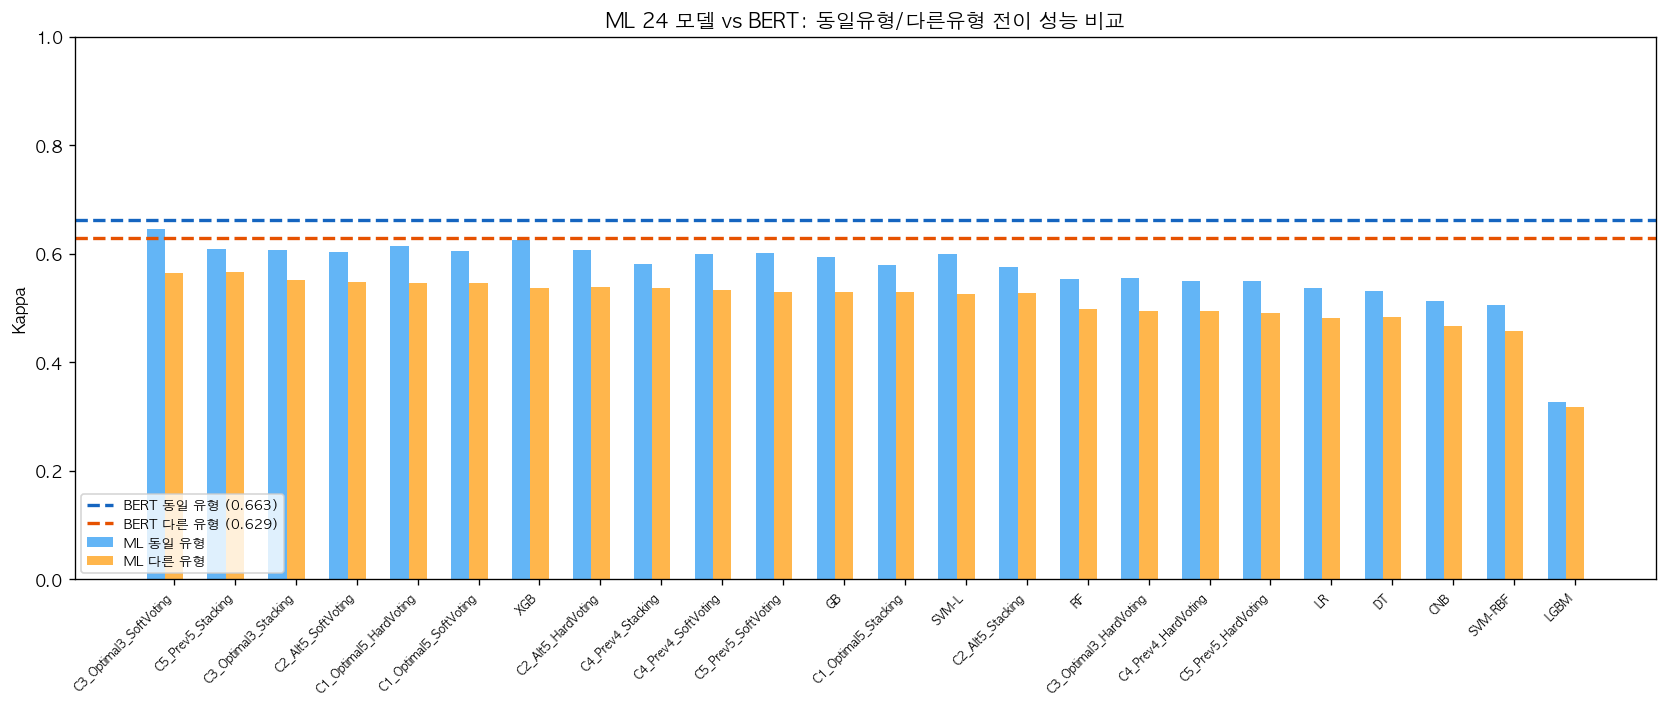


=== ML 24 모델별 동일유형/다른유형 성능 비교 ===


,Model,Within_Type_Kappa,Cross_Type_Kappa,Delta,Overall_Kappa
16,C3_Optimal3_SoftVoting,0.645,0.564,+0.081,0.576
23,C5_Prev5_Stacking,0.610,0.566,+0.044,0.572
17,C3_Optimal3_Stacking,0.608,0.552,+0.055,0.560
13,C2_Alt5_SoftVoting,0.604,0.548,+0.057,0.556
9,C1_Optimal5_HardVoting,0.614,0.546,+0.069,0.555
10,C1_Optimal5_SoftVoting,0.606,0.546,+0.060,0.555
7,XGB,0.625,0.537,+0.088,0.550
12,C2_Alt5_HardVoting,0.608,0.539,+0.068,0.549
20,C4_Prev4_Stacking,0.582,0.538,+0.044,0.544
19,C4_Prev4_SoftVoting,0.600,0.533,+0.067,0.542


In [19]:
# ══════════════════════════════════════════════════════════════
#  ML 전체 24 모델 vs BERT: 동일유형/다른유형 성능 분포
# ══════════════════════════════════════════════════════════════

# 각 ML 모델별 동일유형/다른유형 평균 Kappa 산출
ml_model_summary = []
for model in ML_MODELS:
    mat = ml_matrices_kappa[model]
    within_vals, cross_vals = [], []
    for train_q in ALL_QUESTIONS:
        partner = SAME_TYPE_PARTNER[train_q]
        within_vals.append(mat.loc[train_q, partner])
        for test_q in ALL_QUESTIONS:
            if test_q != train_q and test_q != partner:
                cross_vals.append(mat.loc[train_q, test_q])

    ml_model_summary.append({
        'Model': model,
        'Within_Type_Kappa': np.nanmean(within_vals),
        'Cross_Type_Kappa': np.nanmean(cross_vals),
        'Delta': np.nanmean(within_vals) - np.nanmean(cross_vals),
        'Overall_Kappa': ml_avg_kappa[model]
    })

ml_summary_df = pd.DataFrame(ml_model_summary).sort_values('Overall_Kappa', ascending=False)

# BERT 수치
bert_within = np.nanmean([bert_matrix_kappa.loc[q, SAME_TYPE_PARTNER[q]]
                          for q in ALL_QUESTIONS])
bert_cross_vals = []
for tq in ALL_QUESTIONS:
    for teq in ALL_QUESTIONS:
        if teq != tq and teq != SAME_TYPE_PARTNER[tq]:
            bert_cross_vals.append(bert_matrix_kappa.loc[tq, teq])
bert_cross = np.nanmean(bert_cross_vals)

# 시각화
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(ml_summary_df))
w = 0.3

ax.bar(x - w, ml_summary_df['Within_Type_Kappa'], w,
       label='ML 동일 유형', color='#2196F3', alpha=0.7)
ax.bar(x, ml_summary_df['Cross_Type_Kappa'], w,
       label='ML 다른 유형', color='#FF9800', alpha=0.7)

# BERT 기준선
ax.axhline(y=bert_within, color='#1565C0', linestyle='--', linewidth=2,
           label=f'BERT 동일 유형 ({bert_within:.3f})')
ax.axhline(y=bert_cross, color='#E65100', linestyle='--', linewidth=2,
           label=f'BERT 다른 유형 ({bert_cross:.3f})')

ax.set_xticks(x)
ax.set_xticklabels(ml_summary_df['Model'], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Kappa')
ax.set_title('ML 24 모델 vs BERT: 동일유형/다른유형 전이 성능 비교', fontweight='bold')
ax.legend(loc='lower left', fontsize=8)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

# ML 모델별 상세 테이블
print('\n=== ML 24 모델별 동일유형/다른유형 성능 비교 ===')
display(ml_summary_df.style.format({
    'Within_Type_Kappa': '{:.3f}',
    'Cross_Type_Kappa': '{:.3f}',
    'Delta': '{:+.3f}',
    'Overall_Kappa': '{:.3f}'
}))

---
## 7. 종합 요약 및 결과 저장

### 종합 요약 읽는 법
아래 출력에서 핵심적으로 확인할 수치:

1. **동일 유형 vs 다른 유형 Δ값**
   - Δ가 양수이고 클수록 → 유형 일치가 전이에 중요한 요인
   - ML과 BERT 모두에서 Δ가 양수이면 → 모델 아키텍처에 무관한 강건한 효과

2. **4×4 유형 매트릭스의 대각선 vs 비대각선**
   - 대각선 평균이 비대각선 평균보다 높으면 → 유형 수준에서도 전이 효과 확인
   - 단, 특정 유형(예: 가설평가)이 대각선 값을 끌어올릴 수 있으므로 유형별로 확인 필요

3. **ML vs BERT 비교**
   - BERT 우위 비율과 평균 차이로 어떤 모델이 전반적으로 우수한지 판단
   - 동일유형/다른유형에서 BERT 우위 정도가 다르면 → BERT의 사전학습 표현이 유형 전이에 미치는 효과

In [20]:
# ══════════════════════════════════════════════════════════════
#  종합 요약
# ══════════════════════════════════════════════════════════════

print('=' * 60)
print('  문항 유형별 예측 성능 비교 분석 — 종합 요약')
print('=' * 60)

print('\n■ 문항 유형 분류')
for q_type, qs in TYPE_QUESTIONS.items():
    print(f'  {q_type}: {" ↔ ".join(qs)}')

print(f'\n■ ML Best 모델: {ML_BEST}')

# 동일유형 vs 다른유형
print('\n■ 동일 유형 vs 다른 유형 전이 (Kappa)')
for label, mat in [(f'ML ({ML_BEST})', ml_best_matrix_kappa),
                    ('BERT', bert_matrix_kappa)]:
    within_vals = [mat.loc[q, SAME_TYPE_PARTNER[q]] for q in ALL_QUESTIONS]
    cross_vals = []
    for tq in ALL_QUESTIONS:
        for teq in ALL_QUESTIONS:
            if teq != tq and teq != SAME_TYPE_PARTNER[tq]:
                cross_vals.append(mat.loc[tq, teq])
    w_mean = np.nanmean(within_vals)
    c_mean = np.nanmean(cross_vals)
    print(f'  {label}: 동일유형={w_mean:.3f}, 다른유형={c_mean:.3f}, Δ={w_mean-c_mean:+.3f}')

# 유형별 전이 순위
print('\n■ 4×4 유형 전이 매트릭스 요약')
for label, mat in [('BERT', bert_type_kappa), (f'ML ({ML_BEST})', ml_type_kappa)]:
    print(f'  {label}:')
    for t_type in TYPE_NAMES:
        diag_val = mat.loc[t_type, t_type]
        off_vals = [mat.loc[t_type, o] for o in TYPE_NAMES if o != t_type]
        off_mean = np.nanmean(off_vals)
        print(f'    {t_type}: 동일={diag_val:.3f}, 교차평균={off_mean:.3f}')

# ML vs BERT
print('\n■ ML vs BERT 비교')
same_sub = comp_df[comp_df['Same_Type']]
diff_sub = comp_df[~comp_df['Same_Type']]
print(f'  동일유형: BERT 우위 {(same_sub["BERT_advantage_Kappa"]>0).sum()}/{len(same_sub)}쌍, '
      f'평균 차이={same_sub["BERT_advantage_Kappa"].mean():+.3f}')
print(f'  다른유형: BERT 우위 {(diff_sub["BERT_advantage_Kappa"]>0).sum()}/{len(diff_sub)}쌍, '
      f'평균 차이={diff_sub["BERT_advantage_Kappa"].mean():+.3f}')

  문항 유형별 예측 성능 비교 분석 — 종합 요약

■ 문항 유형 분류
  자료해석·결론: Q1 ↔ Q3
  실험설계: Q2 ↔ Q6
  예측: Q4 ↔ Q5
  가설평가: Q7 ↔ Q8

■ ML Best 모델: C3_Optimal3_SoftVoting

■ 동일 유형 vs 다른 유형 전이 (Kappa)
  ML (C3_Optimal3_SoftVoting): 동일유형=0.645, 다른유형=0.564, Δ=+0.081
  BERT: 동일유형=0.663, 다른유형=0.629, Δ=+0.034

■ 4×4 유형 전이 매트릭스 요약
  BERT:
    자료해석·결론: 동일=0.631, 교차평균=0.664
    실험설계: 동일=0.694, 교차평균=0.670
    예측: 동일=0.584, 교차평균=0.607
    가설평가: 동일=0.741, 교차평균=0.576
  ML (C3_Optimal3_SoftVoting):
    자료해석·결론: 동일=0.609, 교차평균=0.526
    실험설계: 동일=0.678, 교차평균=0.646
    예측: 동일=0.541, 교차평균=0.527
    가설평가: 동일=0.752, 교차평균=0.559

■ ML vs BERT 비교
  동일유형: BERT 우위 5/8쌍, 평균 차이=+0.018
  다른유형: BERT 우위 34/48쌍, 평균 차이=+0.065


In [ ]:
# ══════════════════════════════════════════════════════════════
#  결과 CSV 저장
# ══════════════════════════════════════════════════════════════

output_dir = BASE / 'results' / 'question_type'
output_dir.mkdir(parents=True, exist_ok=True)

# 1) 56개 쌍 상세 비교 (ML Best + BERT)
comp_df.to_csv(output_dir / 'pairwise_56_comparison.csv', index=False)

# 2) BERT 8×8 매트릭스
bert_matrix_kappa.to_csv(output_dir / 'bert_8x8_kappa.csv')
bert_matrix_f1.to_csv(output_dir / 'bert_8x8_f1.csv')

# 3) ML Best 8×8 매트릭스
ml_best_matrix_kappa.to_csv(output_dir / f'ml_best_{ML_BEST}_8x8_kappa.csv')
ml_best_matrix_f1.to_csv(output_dir / f'ml_best_{ML_BEST}_8x8_f1.csv')

# 4) 4×4 유형 매트릭스
bert_type_kappa.to_csv(output_dir / 'bert_4x4_type_kappa.csv')
ml_type_kappa.to_csv(output_dir / f'ml_best_{ML_BEST}_4x4_type_kappa.csv')

# 5) ML 24모델 요약
ml_summary_df.to_csv(output_dir / 'ml_24models_type_summary.csv', index=False)

# 6) 동일유형 vs 다른유형 비교 (개별값 포함)
bert_wc.to_csv(output_dir / 'bert_within_vs_cross_detail.csv', index=False)
ml_wc.to_csv(output_dir / f'ml_best_{ML_BEST}_within_vs_cross_detail.csv', index=False)

# 7) 1Q vs 2Q 비교 — 요약
bert_comp.to_csv(output_dir / 'bert_1q_vs_2q_summary.csv', index=False)
ml_comp.to_csv(output_dir / f'ml_best_{ML_BEST}_1q_vs_2q_summary.csv', index=False)

# 8) 1Q vs 2Q 비교 — 문항별 상세
bert_comp_detail.to_csv(output_dir / 'bert_1q_vs_2q_detail.csv', index=False)
ml_comp_detail.to_csv(output_dir / f'ml_best_{ML_BEST}_1q_vs_2q_detail.csv', index=False)

print(f'결과 저장 완료: {output_dir}/')
for f in sorted(output_dir.glob('*.csv')):
    print(f'  {f.name}')

---
## 8. 유형 수 조합별 전이 성능 분석

### 분석 설계

학습에 사용하는 유형 수(1~3)와 검증 대상 유형 수를 체계적으로 변화시켜,
유형 기반 일반화 패턴을 분석한다. 학습 시 유형당 사용 문항 수(1문항/2문항)도 구분한다.

| 학습 유형 수 | 학습 문항/유형 | 검증 유형 수 | 비고 |
|:---:|:---:|:---:|------|
| 1 | 1문항 / 2문항 | 1, 2, 3 | 나머지 3개 유형 중 선택 |
| 2 | 1문항 / 2문항 | 1, 2 | 나머지 2개 유형 중 선택 |
| 3 | 1문항 / 2문항 | 1 | 나머지 1개 유형 |

### 읽는 법
- **1문항/유형**: 각 유형에서 1개 문항만 선택하여 학습 (모든 선택지의 평균)
- **2문항/유형**: 각 유형의 2개 문항 모두 사용하여 학습
- **ML 평균 Kappa**: 24개 ML 알고리즘의 Kappa 평균
- **ML 최고 Kappa**: 24개 ML 알고리즘 중 가장 높은 Kappa
- 검증은 항상 학습에 사용하지 않은 **다른 유형**의 문항에 대해 수행
- Kappa는 검증 대상 유형의 **모든 문항을 합산**하여 산출

In [22]:
# ══════════════════════════════════════════════════════════════
#  유형 수 조합별 전이 성능 — 계산
# ══════════════════════════════════════════════════════════════

from itertools import combinations, product as iproduct

# --- Prediction 파일 캐시 ---
_pred_cache_ml = {}
_pred_cache_bert = {}

# 이미 로드된 데이터 캐시 등록
for q in ALL_QUESTIONS:
    _pred_cache_ml[q] = ml_preds_1q[q]
    _pred_cache_bert[q] = bert_preds_1q[q]
for combo_key in ml_preds_2q:
    _pred_cache_ml[combo_key] = ml_preds_2q[combo_key]
for combo_key in bert_preds_2q:
    _pred_cache_bert[combo_key] = bert_preds_2q[combo_key]


def _load_ml(combo_name):
    if combo_name not in _pred_cache_ml:
        path = ML_PRED_DIR / f'predictions_{combo_name}.xlsx'
        if path.exists():
            df = pd.read_excel(path)
            df['question'] = parse_question(df['id'])
            _pred_cache_ml[combo_name] = df
        else:
            _pred_cache_ml[combo_name] = None
    return _pred_cache_ml[combo_name]


def _load_bert(combo_name):
    if combo_name not in _pred_cache_bert:
        for pod in range(1, 5):
            path = BERT_BASE / f'results {pod}' / 'predictions' / f'qc_pred_{combo_name}.xlsx'
            if path.exists():
                df = pd.read_excel(path)
                df['question'] = parse_question(df['id'])
                _pred_cache_bert[combo_name] = df
                break
        else:
            _pred_cache_bert[combo_name] = None
    return _pred_cache_bert[combo_name]


def _sort_qs(qs):
    return sorted(qs, key=lambda q: int(q[1]))


def _combo_name(qs):
    return '_'.join(_sort_qs(qs))


# --- 모든 구성 생성 ---
type_configs = []

for n_train_types in [1, 2, 3]:
    for train_type_combo in combinations(TYPE_NAMES, n_train_types):
        other_types = [t for t in TYPE_NAMES if t not in train_type_combo]

        for n_test_types in range(1, len(other_types) + 1):
            for test_type_combo in combinations(other_types, n_test_types):
                # 테스트 문항
                test_qs = []
                for tt in test_type_combo:
                    test_qs.extend(TYPE_QUESTIONS[tt])
                test_qs = _sort_qs(test_qs)

                # === 1문항/유형 ===
                type_q_opts = [TYPE_QUESTIONS[tt] for tt in train_type_combo]
                for q_sel in iproduct(*type_q_opts):
                    train_qs = _sort_qs(list(q_sel))
                    type_configs.append({
                        'n_train_types': n_train_types,
                        'n_test_types': n_test_types,
                        'q_per_type': 1,
                        'train_types': list(train_type_combo),
                        'test_types': list(test_type_combo),
                        'train_qs': train_qs,
                        'test_qs': test_qs,
                        'combo': _combo_name(train_qs),
                    })

                # === 2문항/유형 ===
                train_qs_full = []
                for tt in train_type_combo:
                    train_qs_full.extend(TYPE_QUESTIONS[tt])
                train_qs_full = _sort_qs(train_qs_full)
                type_configs.append({
                    'n_train_types': n_train_types,
                    'n_test_types': n_test_types,
                    'q_per_type': 2,
                    'train_types': list(train_type_combo),
                    'test_types': list(test_type_combo),
                    'train_qs': train_qs_full,
                    'test_qs': test_qs,
                    'combo': _combo_name(train_qs_full),
                })

unique_combos = set(c['combo'] for c in type_configs)
print(f'총 구성: {len(type_configs)}개, 고유 학습 조합: {len(unique_combos)}개')

# --- Kappa 산출 ---
print('예측 파일 로드 및 kappa 계산 중...')

tc_rows = []
for i, cfg in enumerate(type_configs):
    combo = cfg['combo']
    test_qs = cfg['test_qs']

    # ML
    ml_df = _load_ml(combo)
    ml_kappas = {}
    n_samples = 0
    if ml_df is not None:
        sub = ml_df[ml_df['question'].isin(test_qs)]
        n_samples = len(sub)
        if n_samples >= 2:
            y_true = sub['true_label']
            for model in ML_MODELS:
                pred_col = get_pred_col(model)
                if pred_col in sub.columns:
                    try:
                        ml_kappas[model] = cohen_kappa_score(y_true, sub[pred_col])
                    except:
                        pass

    # BERT
    bert_df = _load_bert(combo)
    bert_kappa = np.nan
    if bert_df is not None:
        sub_b = bert_df[bert_df['question'].isin(test_qs)]
        if len(sub_b) >= 2:
            try:
                bert_kappa = cohen_kappa_score(sub_b['true_label'], sub_b['predicted_label'])
            except:
                pass

    ml_vals = list(ml_kappas.values())
    tc_rows.append({
        'n_train_types': cfg['n_train_types'],
        'n_test_types': cfg['n_test_types'],
        'q_per_type': cfg['q_per_type'],
        'train_types': '+'.join(cfg['train_types']),
        'test_types': '+'.join(cfg['test_types']),
        'train_qs': ','.join(cfg['train_qs']),
        'test_qs': ','.join(cfg['test_qs']),
        'combo': combo,
        'ML_Mean_Kappa': np.mean(ml_vals) if ml_vals else np.nan,
        'ML_Max_Kappa': np.max(ml_vals) if ml_vals else np.nan,
        'ML_Best_Model': max(ml_kappas, key=ml_kappas.get) if ml_kappas else '',
        'BERT_Kappa': bert_kappa,
        'N_test': n_samples,
    })

    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(type_configs)} 완료')

type_combo_df = pd.DataFrame(tc_rows)
print(f'\n완료: {len(type_combo_df)}개 결과')
print(f'ML: {type_combo_df["ML_Mean_Kappa"].notna().sum()}, '
      f'BERT: {type_combo_df["BERT_Kappa"].notna().sum()}')

총 구성: 210개, 고유 학습 조합: 78개
예측 파일 로드 및 kappa 계산 중...
  50/210 완료
  100/210 완료
  150/210 완료
  200/210 완료

완료: 210개 결과
ML: 210, BERT: 210


In [ ]:
# ══════════════════════════════════════════════════════════════
#  요약 테이블: (학습 유형 수 × 검증 유형 수 × 문항/유형)
# ══════════════════════════════════════════════════════════════

summary_tc = type_combo_df.groupby(
    ['n_train_types', 'n_test_types', 'q_per_type']
).agg(
    N=('ML_Mean_Kappa', 'count'),
    ML_Mean_avg=('ML_Mean_Kappa', 'mean'),
    ML_Mean_std=('ML_Mean_Kappa', 'std'),
    ML_Max_avg=('ML_Max_Kappa', 'mean'),
    ML_Max_std=('ML_Max_Kappa', 'std'),
    BERT_avg=('BERT_Kappa', 'mean'),
    BERT_std=('BERT_Kappa', 'std'),
).reset_index()

# 표시용 포맷
summary_tc['ML 평균'] = summary_tc.apply(
    lambda r: f"{r['ML_Mean_avg']:.3f} ± {r['ML_Mean_std']:.3f}"
    if pd.notna(r['ML_Mean_std']) else f"{r['ML_Mean_avg']:.3f}", axis=1)
summary_tc['ML 최고'] = summary_tc.apply(
    lambda r: f"{r['ML_Max_avg']:.3f} ± {r['ML_Max_std']:.3f}"
    if pd.notna(r['ML_Max_std']) else f"{r['ML_Max_avg']:.3f}", axis=1)
summary_tc['BERT'] = summary_tc.apply(
    lambda r: f"{r['BERT_avg']:.3f} ± {r['BERT_std']:.3f}"
    if pd.notna(r['BERT_std']) else f"{r['BERT_avg']:.3f}", axis=1)

disp = summary_tc[['n_train_types', 'n_test_types', 'q_per_type',
                    'N', 'ML 평균', 'ML 최고', 'BERT']].copy()
disp.columns = ['학습 유형 수', '검증 유형 수', '문항/유형',
                '조합 수', 'ML 평균 Kappa', 'ML 최고 Kappa', 'BERT Kappa']

print('=== 유형 수 조합별 전이 성능 요약 ===')
print('  (값 = 해당 조건 내 모든 구성의 평균 ± 표준편차)\n')
display(disp)

# --- 상세: 특정 유형 쌍별 결과 (1→1, 2문항) ---
print('\n=== 유형 쌍별 상세 결과 (1유형 학습 → 1유형 검증, 2문항/유형) ===')
detail_1to1 = type_combo_df[
    (type_combo_df['n_train_types'] == 1) &
    (type_combo_df['n_test_types'] == 1) &
    (type_combo_df['q_per_type'] == 2)
][['train_types', 'test_types', 'train_qs', 'test_qs',
   'ML_Mean_Kappa', 'ML_Max_Kappa', 'ML_Best_Model', 'BERT_Kappa']].copy()
detail_1to1 = detail_1to1.sort_values('ML_Max_Kappa', ascending=False)
display(detail_1to1.round(4).reset_index(drop=True))

# CSV 저장
out_dir = Path('../4_llm/results/full_evaluation/type_combo')
out_dir.mkdir(parents=True, exist_ok=True)
type_combo_df.to_csv(out_dir / 'type_combo_all_results.csv', index=False)
summary_tc.to_csv(out_dir / 'type_combo_summary.csv', index=False)
print(f'\n저장: {out_dir}')

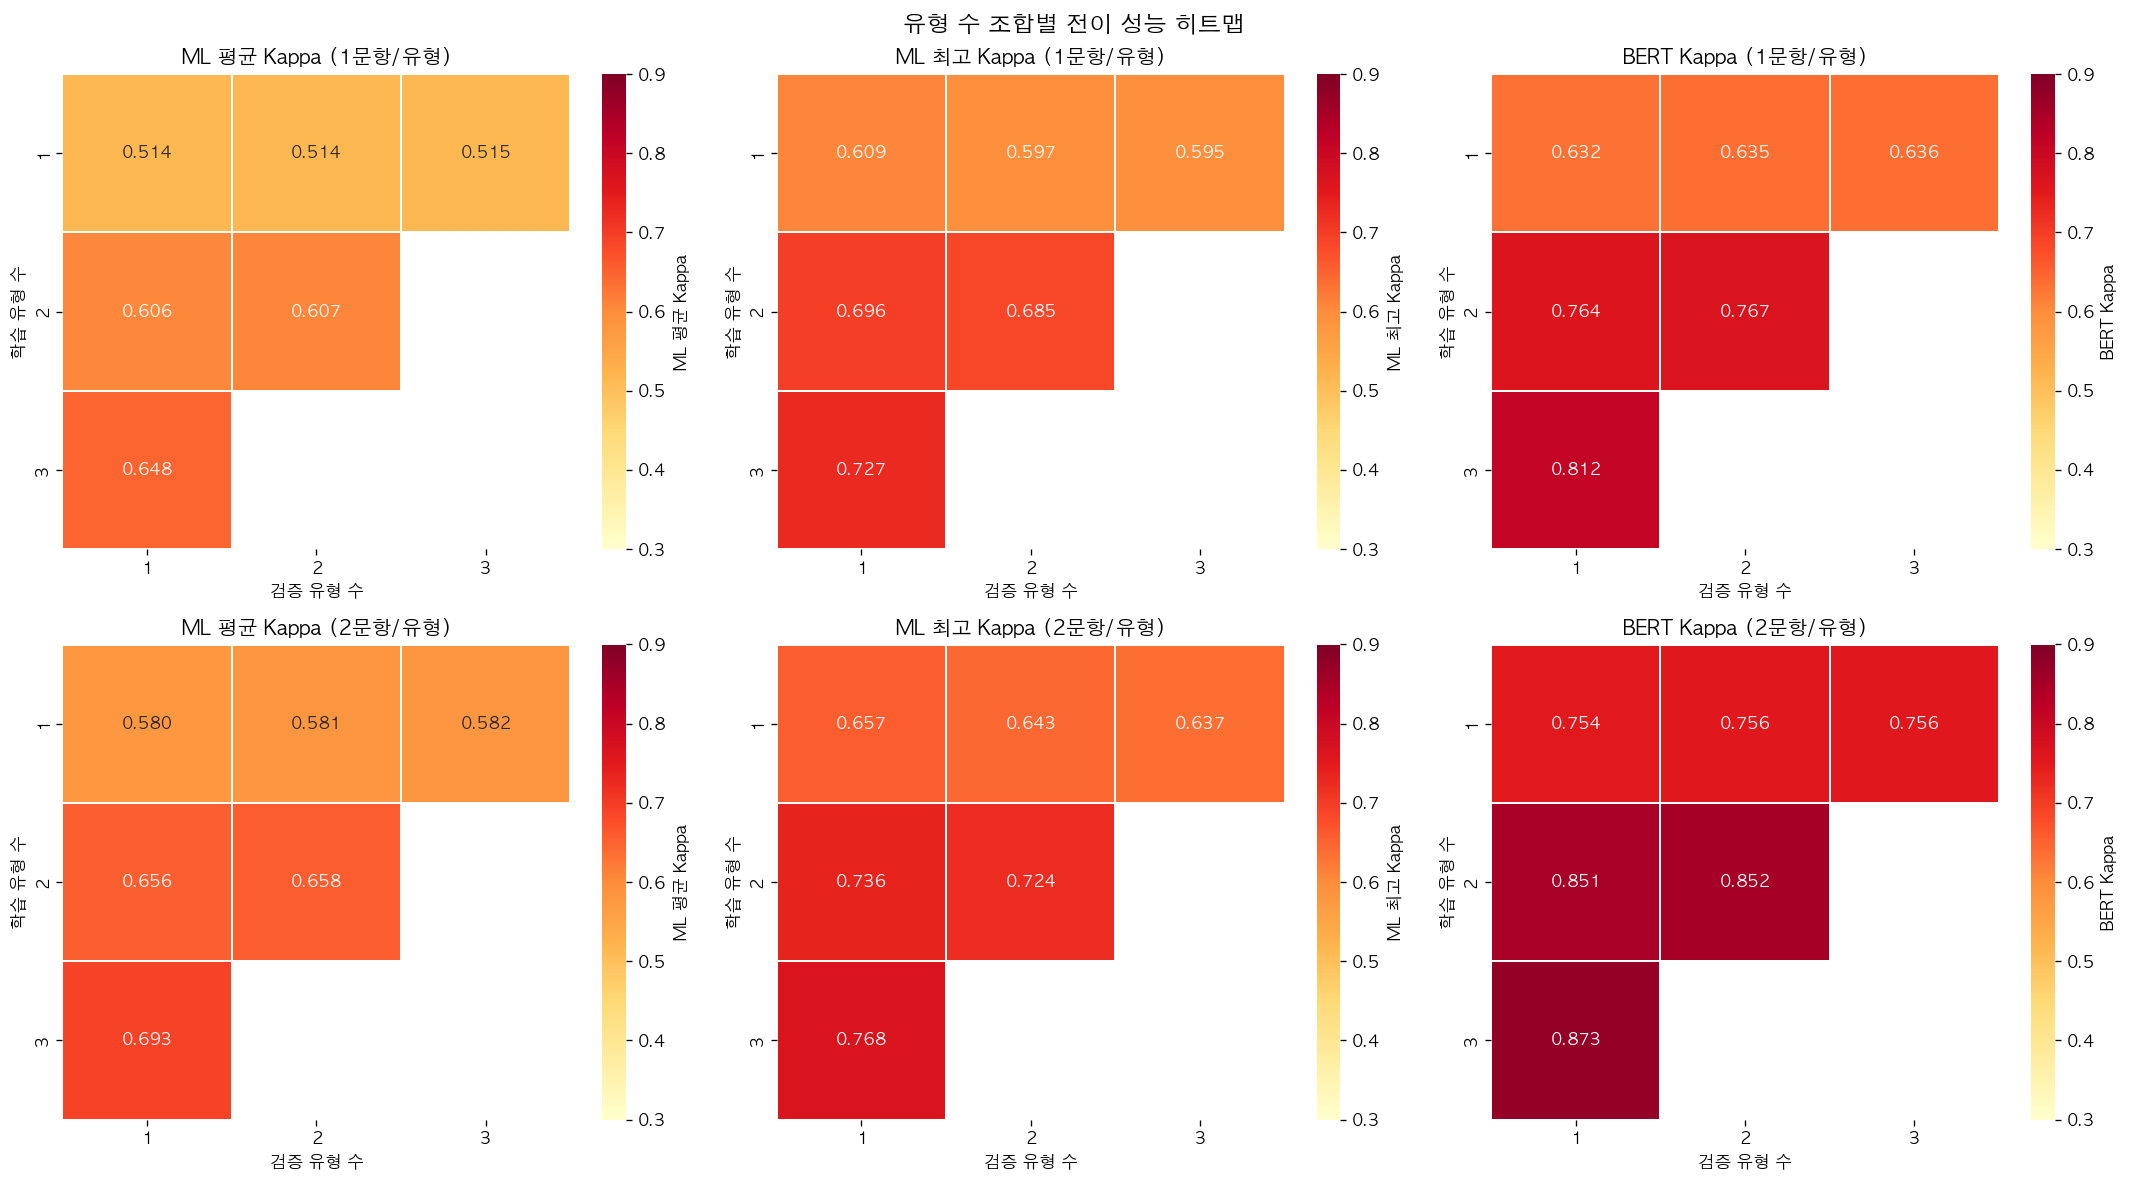

저장: type_combo_analysis/type_combo_heatmap.png


In [24]:
# ══════════════════════════════════════════════════════════════
#  시각화 1: 히트맵 (학습 유형 수 × 검증 유형 수)
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_info = [
    ('ML_Mean_Kappa', 'ML 평균 Kappa'),
    ('ML_Max_Kappa', 'ML 최고 Kappa'),
    ('BERT_Kappa', 'BERT Kappa'),
]

for row_idx, qpt in enumerate([1, 2]):
    for col_idx, (metric, label) in enumerate(metrics_info):
        ax = axes[row_idx, col_idx]
        mat = pd.DataFrame(np.nan, index=[1, 2, 3], columns=[1, 2, 3])

        for n_tr in [1, 2, 3]:
            for n_te in range(1, 4 - n_tr + 1):
                sub = type_combo_df[
                    (type_combo_df['n_train_types'] == n_tr) &
                    (type_combo_df['n_test_types'] == n_te) &
                    (type_combo_df['q_per_type'] == qpt)
                ]
                if len(sub) > 0:
                    mat.loc[n_tr, n_te] = sub[metric].mean()

        sns.heatmap(mat, annot=True, fmt='.3f', cmap='YlOrRd',
                    vmin=0.3, vmax=0.9, ax=ax,
                    linewidths=1, linecolor='white',
                    cbar_kws={'label': label})
        ax.set_xlabel('검증 유형 수')
        ax.set_ylabel('학습 유형 수')
        ax.set_title(f'{label} ({qpt}문항/유형)', fontweight='bold')

fig.suptitle('유형 수 조합별 전이 성능 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
out_fig = out_dir / 'type_combo_heatmap.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out_fig}')

**결과 해석:**

학습 유형 수 x 검증 유형 수 히트맵입니다. 행은 학습에 사용한 유형 수, 열은 테스트 대상 유형 수를 나타냅니다.

- **학습 유형이 많을수록 성능 향상**: 1유형 -> 2유형 -> 3유형으로 학습 유형이 증가하면 전반적인 전이 성능이 향상
- **ML vs BERT**: BERT가 모든 조건에서 ML을 상회하며, 특히 학습 유형이 적을 때(1유형) 격차가 큼 → BERT의 사전학습 지식이 부족한 학습 데이터를 보완
- **유형당 문항 수 효과**: 유형당 2문항이 1문항보다 일관되게 높은 성능 → 동일 유형의 다양한 문항이 학습에 도움

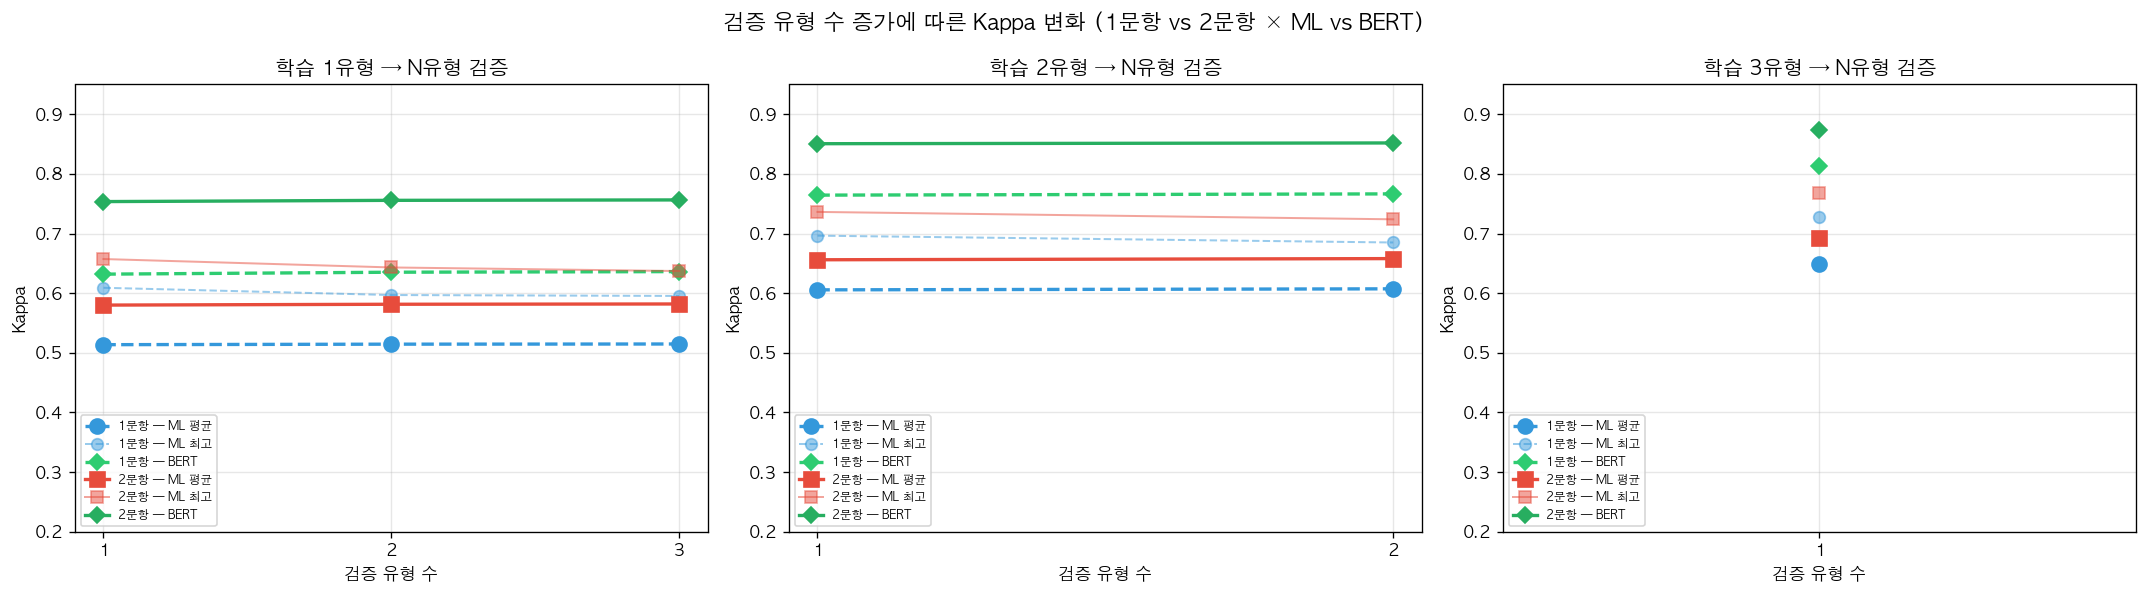

저장: type_combo_analysis/type_combo_trend.png


In [25]:
# ══════════════════════════════════════════════════════════════
#  시각화 2: 학습 유형 수별 검증 유형 수에 따른 성능 추이
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {1: '#3498db', 2: '#e74c3c'}
styles = {1: 'o--', 2: 's-'}

for idx, n_train in enumerate([1, 2, 3]):
    ax = axes[idx]
    max_test = 4 - n_train

    for qpt in [1, 2]:
        sub = type_combo_df[
            (type_combo_df['n_train_types'] == n_train) &
            (type_combo_df['q_per_type'] == qpt)
        ]
        if sub.empty:
            continue

        # ML Mean Kappa
        grp_mean = sub.groupby('n_test_types')['ML_Mean_Kappa'].mean()
        ax.plot(grp_mean.index, grp_mean.values, styles[qpt],
                color=colors[qpt], linewidth=2, markersize=9,
                label=f'{qpt}문항 — ML 평균')

        # ML Max Kappa
        grp_max = sub.groupby('n_test_types')['ML_Max_Kappa'].mean()
        ax.plot(grp_max.index, grp_max.values, styles[qpt],
                color=colors[qpt], linewidth=1.2, alpha=0.5, markersize=7,
                label=f'{qpt}문항 — ML 최고')

        # BERT
        grp_bert = sub.groupby('n_test_types')['BERT_Kappa'].mean()
        marker = 'D--' if qpt == 1 else 'D-'
        ax.plot(grp_bert.index, grp_bert.values, marker,
                color='#2ecc71' if qpt == 1 else '#27ae60',
                linewidth=2, markersize=7,
                label=f'{qpt}문항 — BERT')

    ax.set_xlabel('검증 유형 수')
    ax.set_ylabel('Kappa')
    ax.set_title(f'학습 {n_train}유형 → N유형 검증', fontweight='bold')
    ax.set_xticks(range(1, max_test + 1))
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.2, 0.95)

plt.suptitle('검증 유형 수 증가에 따른 Kappa 변화 (1문항 vs 2문항 × ML vs BERT)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_fig2 = out_dir / 'type_combo_trend.png'
plt.savefig(out_fig2, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out_fig2}')

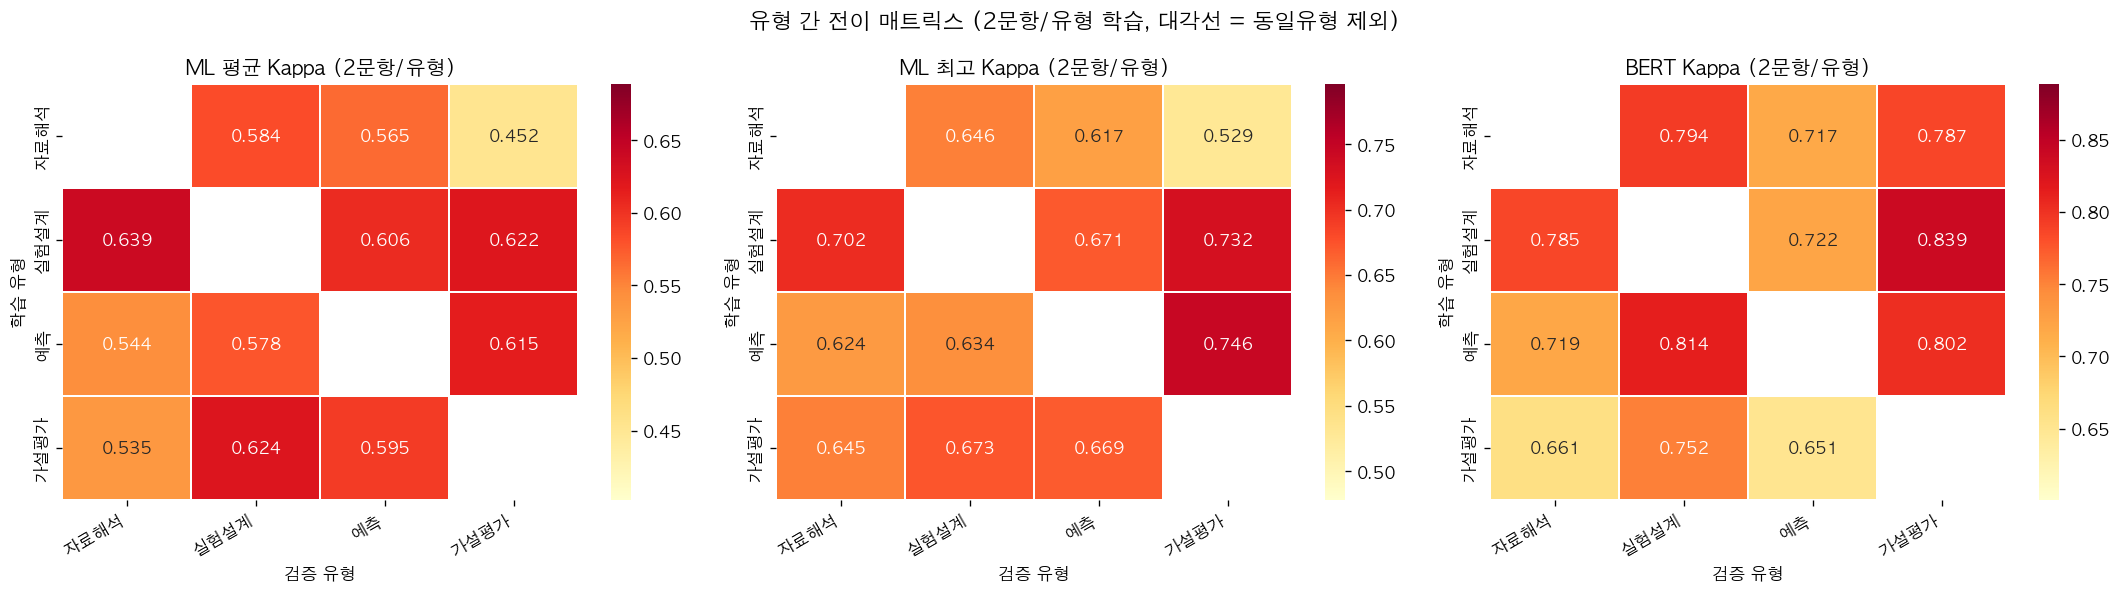

저장: type_combo_analysis/type_pair_heatmap_2q.png


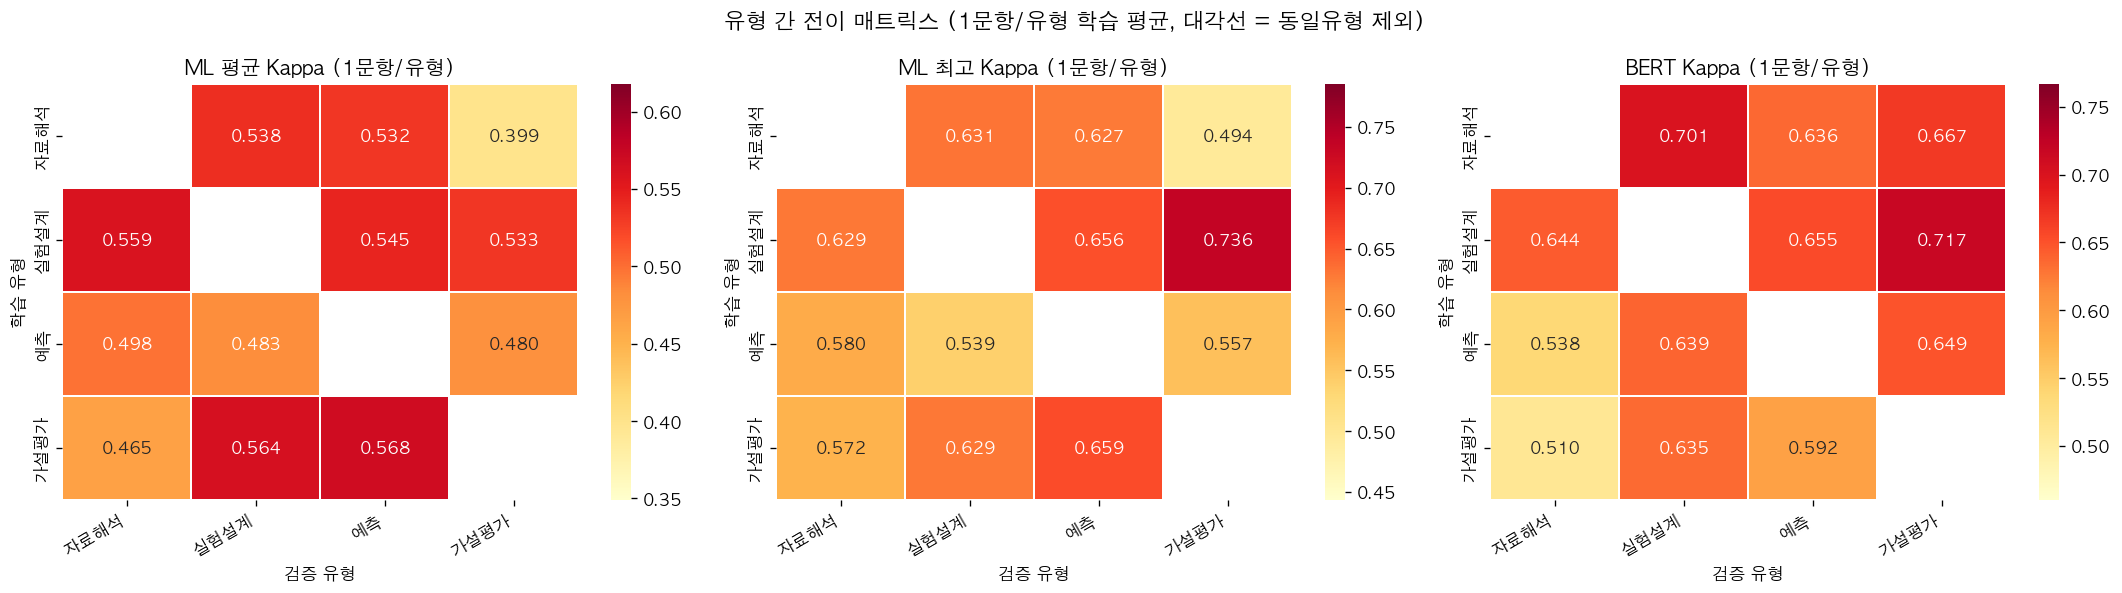

저장: type_combo_analysis/type_pair_heatmap_1q.png


In [26]:
# ══════════════════════════════════════════════════════════════
#  시각화 3: 유형 쌍별 4×4 전이 매트릭스 (2문항/유형)
#  기존 분석4의 4×4와 대비: 여기서는 2문항으로 학습한 결과
# ══════════════════════════════════════════════════════════════

# 1유형→1유형, 2문항/유형 결과로 4×4 매트릭스 구성
detail_2q = type_combo_df[
    (type_combo_df['n_train_types'] == 1) &
    (type_combo_df['n_test_types'] == 1) &
    (type_combo_df['q_per_type'] == 2)
].copy()

# 짧은 유형 이름
short_names = {'자료해석·결론': '자료해석', '실험설계': '실험설계',
               '예측': '예측', '가설평가': '가설평가'}
type_order = ['자료해석·결론', '실험설계', '예측', '가설평가']
short_order = [short_names[t] for t in type_order]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['ML 평균 Kappa (2문항/유형)', 'ML 최고 Kappa (2문항/유형)', 'BERT Kappa (2문항/유형)']
metrics = ['ML_Mean_Kappa', 'ML_Max_Kappa', 'BERT_Kappa']

for ax_idx, (metric, title) in enumerate(zip(metrics, titles)):
    mat = pd.DataFrame(np.nan, index=short_order, columns=short_order)
    for _, row in detail_2q.iterrows():
        tr = short_names.get(row['train_types'], row['train_types'])
        te = short_names.get(row['test_types'], row['test_types'])
        if tr in mat.index and te in mat.columns:
            mat.loc[tr, te] = row[metric]

    vals = mat.values[~np.isnan(mat.values)]
    if len(vals) > 0:
        vm = max(0, vals.min() - 0.05)
        vx = min(1, vals.max() + 0.05)
    else:
        vm, vx = 0, 1

    sns.heatmap(mat, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=vm, vmax=vx, ax=axes[ax_idx],
                linewidths=1, linecolor='white')
    axes[ax_idx].set_xlabel('검증 유형')
    axes[ax_idx].set_ylabel('학습 유형')
    axes[ax_idx].set_title(title, fontweight='bold')
    axes[ax_idx].set_xticklabels(axes[ax_idx].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('유형 간 전이 매트릭스 (2문항/유형 학습, 대각선 = 동일유형 제외)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_fig3 = out_dir / 'type_pair_heatmap_2q.png'
plt.savefig(out_fig3, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out_fig3}')

# --- 1문항/유형 평균도 표시 ---
detail_1q = type_combo_df[
    (type_combo_df['n_train_types'] == 1) &
    (type_combo_df['n_test_types'] == 1) &
    (type_combo_df['q_per_type'] == 1)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles_1q = ['ML 평균 Kappa (1문항/유형)', 'ML 최고 Kappa (1문항/유형)', 'BERT Kappa (1문항/유형)']

for ax_idx, (metric, title) in enumerate(zip(metrics, titles_1q)):
    mat = pd.DataFrame(np.nan, index=short_order, columns=short_order)

    # 1문항은 각 유형 쌍에 여러 선택지 → 평균
    grp = detail_1q.groupby(['train_types', 'test_types'])[metric].mean()
    for (tr_raw, te_raw), val in grp.items():
        tr = short_names.get(tr_raw, tr_raw)
        te = short_names.get(te_raw, te_raw)
        if tr in mat.index and te in mat.columns:
            mat.loc[tr, te] = val

    vals = mat.values[~np.isnan(mat.values)]
    if len(vals) > 0:
        vm = max(0, vals.min() - 0.05)
        vx = min(1, vals.max() + 0.05)
    else:
        vm, vx = 0, 1

    sns.heatmap(mat, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=vm, vmax=vx, ax=axes[ax_idx],
                linewidths=1, linecolor='white')
    axes[ax_idx].set_xlabel('검증 유형')
    axes[ax_idx].set_ylabel('학습 유형')
    axes[ax_idx].set_title(title, fontweight='bold')
    axes[ax_idx].set_xticklabels(axes[ax_idx].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('유형 간 전이 매트릭스 (1문항/유형 학습 평균, 대각선 = 동일유형 제외)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_fig4 = out_dir / 'type_pair_heatmap_1q.png'
plt.savefig(out_fig4, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out_fig4}')